## Visualization Code V03 - Release version

This is a first release of final github code. All figures from the paper have been added to the code and are tested as working. Streamlined and formatting issues corrected from V02. 

This script will reproduce figures in "Realism of 3D Ocean Dynamics Represented by 2D Empirical Orthogonal Functions: 3D versus 2D Comparison and Interpretation Using Global Ocean Physics Reanalysis Data"

# Initialize Workspace

## Load packages

In [1]:
# --- Standard library ---
import os
import math
import time
import csv
import string
import warnings

# --- Numerical / data ---
import numpy as np
from numpy import meshgrid
import pandas as pd

# --- Scientific I/O ---
import scipy.io as sc
import netCDF4 as nc
from netCDF4 import Dataset as ds

# --- Stats ---
from scipy.stats import pearsonr, linregress

# --- Plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm, ticker
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plots
# (If you never call Axes3D directly, you can remove this; 3D often works via projection='3d')

# --- Widgets / Media ---
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
import imageio

import warnings
warnings.filterwarnings("ignore")

## Define Functions

In [2]:
# --- Block-shared: directory + folder creation ---

def set_directory():
    global data_directory
    path = 'F:/GLORYS/'
    if not os.path.exists(path):
        data_directory = '/Volumes/Elements/GLORYS'
    else:
        data_directory = path
    return


# Function creates a folder if it doesnt already exist
# Input:
#         - folder_path: string with the path name to folder
def create_folder(folder_path):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"Folder '{folder_path}' created.")
    else:
        print(f"Folder '{folder_path}' already exists.")


# Keep the original side-effect call (since your script may rely on it)
set_directory()


# --- Shared: volume weights (identical across all 3 blocks) ---

def vol_weight(depths, lon, lat):
    xx, yy = meshgrid(lon, lat)
    tot_depth = len(depths)

    # area weight for lattitude values
    area_w = np.cos(yy * math.pi / 180)
    if lat[-1] == 90.0:
        area_w[-1, :] = 0.0

    # area weights for depth
    area_weight = []
    for i in range(tot_depth):
        if i == 0:
            area_weight.append(np.sqrt(depths[0] * area_w))  # first depth thickness
        else:
            area_weight.append(np.sqrt((depths[i] - depths[i - 1]) * area_w))

    # Turning weights into one array
    area_weight = np.array(area_weight)
    return area_weight


# --- Present only in Block 1 ---

def get_var():
    fn = 'thetao.mon.mean.1994.nc'
    fn = os.path.join(data_directory, fn)
    fn = ds(fn, 'r')
    lat = fn.variables['latitude'][:].data    # read in latitude
    lon = fn.variables['longitude'][:].data   # read in longitude
    depths = fn.variables['depth'][:].data    # read in depth
    fn.close()
    return lat, lon, depths


def read_EOFs(mode, EOF_directory):
    fn = 'EOF_' + str(mode) + '.nc'
    fn = os.path.join(EOF_directory, fn)  # join with EOF path
    EOF_ncfile = ds(fn, 'r')
    EOF = EOF_ncfile.variables['EOF']
    EOF = EOF[:].filled()
    EOF_ncfile.close()

    area_weight = vol_weight(cut_depths, cut_lon, cut_lat)
    EOF = EOF / area_weight  # remember to div by area weight
    return EOF


# --- Present in Blocks 2 and 3 (identical) ---

def format_longitude(longitude):
    if not 0 <= longitude <= 360:
        return "Invalid longitude. Must be between 0 and 360 degrees."

    if longitude == 0:
        hemisphere = ''
        degrees = longitude
    elif longitude < 180:
        hemisphere = 'E'
        degrees = longitude
    elif longitude == 180:
        hemisphere = ''
        degrees = longitude
    else:
        hemisphere = 'W'
        degrees = 360 - longitude

    return f"{degrees:.0f}{hemisphere}"


def format_latitude(latitude):
    if not -90 <= latitude <= 90:
        return "Invalid latitude. Must be between -90 and 90 degrees."

    if latitude > 0:
        hemisphere = "N"
    elif latitude == 0:
        hemisphere = ""
    else:
        hemisphere = 'S'

    degrees = abs(latitude)
    return f"{degrees:.0f}{hemisphere}"


# --- Present only in Block 3 ---

def convert_longitude(lon_0_360):
    lon_180_w_180_e = lon_0_360 - 360 if lon_0_360 > 180 else lon_0_360
    if lon_180_w_180_e < 0:
        lon_180_w_180_e = abs(lon_180_w_180_e)
        convert = f"{lon_180_w_180_e}$^\xb0$W"
    else:
        convert = f"{lon_180_w_180_e}$^\xb0$E"
    return convert


def get_lat_names(lat_ind):
    lat_name = int(cut_lat[lat_ind])
    if lat_name < 0:
        lat_name = f"{abs(lat_name)}$^\xb0$S"
    elif lat_name == 0:
        lat_name = 'Equator'
    else:
        lat_name = f"{lat_name}$^\xb0$N"
    return lat_name

#################################################################################################################
#################################################################################################################
# Function reads in raw cut anomalies
#
# Input:
#         - year: int with the specific year to read
# Output:
#         - anom: 3D array of dim (depth, lat, lon) with the anomaly data
def read_anom_raw(year):
    fn   = month +'.anom.mon.'+str(year)+'.nc'        # change directory
    fn   = os.path.join(anomalies_directory, fn)  # join with the directory that can be changed
    nc0 = ds(fn, 'r')
    anom = nc0.variables['anom'][:depth_end, lat_start:lat_end, lon_start:lon_end]
    anom = anom.filled()
    nc0.close()
    return anom
#################################################################################################################
#################################################################################################################
# Function reads in cut anomalies, will tak eout NaNs, and then flattten to a 1D array
#
# Input:
#         - year: int with the year to read in
# Output:
#         - anom: 1d array that contains anomalies of the file without any NaN
def read_cut_anom_compressed(year,lat_cut_start,lat_cut_end, lon_cut_start, lon_cut_end):
    fn   = month + '.anom.mon.'+str(year)+'.nc'        # change directory
    fn   = os.path.join(anomalies_directory, fn)  # join with the directory that can be changed
    nc0  = ds(fn, 'r')
    anom = nc0.variables['anom'][0, lat_cut_start:lat_cut_end, lon_cut_start:lon_cut_end]
    anom = anom.compressed()                        # flatttentens and gets rid of NaN
    #anom = anom.filled()
    nc0.close()
    return anom
#################################################################################################################
#################################################################################################################
# Function wil read clinatologies at the cut given
# Input:
#        - depth_end: Int defining what depth level to stop it
#        - lat_start: Int defining which lat to start at
#        - lat_end: Int defining which lat to stop at
#        - lon_start: Int defining which lon to start
#        - lon_end: Int defining which lon to end at
# Output:
#         - clim: 3D float array with the climatologies at a defined cut
def read_sdev_compressed(lat_cut_start,lat_cut_end, lon_cut_start, lon_cut_end):
    fn = 'Winter.mon.sdev.nc'
    # read in climatologies
    fn = os.path.join(anomalies_directory, fn)
    nc0 = ds(fn, 'r')
    sdev = nc0.variables['sdev'][0, lat_cut_start:lat_cut_end, lon_cut_start:lon_cut_end] 
    sdev = sdev.compressed()               # cut clim
    nc0.close()
    return sdev


import pandas as pd
'''
Read eigenvalues and eigenvectors from the Excel file.

Parameters:
-----------
month : str
    Month identifier used in the filename
EOF_directory : str
    Directory where the file is stored

Returns:
--------
eigvals : numpy.ndarray
    Array of eigenvalues with shape (n_eigvals, n_depths)
eigvecs : numpy.ndarray
    Array of eigenvectors with shape (n_depths, n_locations, n_eigvals)
'''
def read_evals(month, EOF_directory):

    
    # Construct filename
    fn = month + '_eigenvalues_eigenvectors.xlsx'
    EOF_directory = os.path.join(data_directory, '2D EOFs/Winter Avg/Global/')
    fn = os.path.join(EOF_directory, fn)
    
    # Read all sheets from the Excel file
    xl_file = pd.ExcelFile(fn)
    
    # Get the number of depth bins from sheet names
    sheet_names = xl_file.sheet_names
    n_depths = len(sheet_names)
    
    # Read first sheet to get dimensions
    df_first = pd.read_excel(xl_file, sheet_name=sheet_names[0], index_col=0)
    n_eigvals = len(df_first)  # number of rows
    n_locations = df_first.shape[1] - 1  # excluding eigenvalue column
    
    # Initialize arrays
    eigvals = np.zeros((n_eigvals, n_depths))
    eigvecs = np.zeros((n_depths, n_locations, n_eigvals))
    
    # Read data from each sheet
    for depth_idx, sheet_name in enumerate(sheet_names):
        df = pd.read_excel(xl_file, sheet_name=sheet_name, index_col=0)
        
        # Extract eigenvalues (first column)
        eigvals[:, depth_idx] = df.iloc[:, 0].values
        
        # Extract eigenvectors (remaining columns)
        # Note: eigenvectors are stored transposed in the file
        eigvecs[depth_idx, :, :] = df.iloc[:, 1:].values.T
    
    return eigvals, eigvecs


## Define Variables

In [3]:
month = 'Winter Avg'

# --- Load lat/lon/depth metadata from an anomalies file ---
fn = 'Anomalies/Jan/Jan.anom.mon.1993.nc'
fn = os.path.join(data_directory, fn)
fn = ds(fn, 'r')
lat    = fn.variables['lat'][:].data
lon    = fn.variables['lon'][:].data
depths = fn.variables['Z'][:].data
fn.close()


####### SELECT REGION ########

# Global 
region = "Global"
lat_start = 0
lat_end   = len(lat)
lon_start = 0
lon_end   = len(lon)
depth_end = len(depths)

############################

EOF_directory = os.path.join(data_directory, '2D EOFs/' + month + "/" + region + "/")
create_folder(EOF_directory)
anomalies_directory = os.path.join(data_directory, 'Anomalies/Winter Avg')

years = np.linspace(1994, 2021, 28, dtype="int")
cut_lat    = lat[lat_start:lat_end]
cut_lon    = lon[lon_start:lon_end]
cut_depths = depths[:depth_end]


top2 = cm.get_cmap('winter')
bottom2 = cm.get_cmap('hot_r')
newcolors2 = np.vstack((top2(np.linspace(0, 1, 128)),   # I want all of the winter cmap and it will only explain 100 points
                    bottom2(np.linspace(.1, .9, 128)))) # I dont want the extremes of hot cmap but it will explain 128 points
newcmp2 = ListedColormap(newcolors2, name='OrangeBlue')
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug','Sep', 'Oct', 'Nov', 'Dec']

Folder 'F:/GLORYS/2D EOFs/Winter Avg/Global/' already exists.


# Figure 2 and 14 Data Cleaning

## Read in 2D Eigenvalues

In [4]:
import pandas as pd

fn = 'F:/GLORYS/2D EOFs/Winter Avg/' + region + '/Winter Avg_eigenvalues_eigenvectors.xlsx'


def read_eigenvalues_to_array(file_path):
    """
    Reads the 'Eigenvalue' column from all sheets in an Excel file and returns a NumPy array.

    Args:
        file_path (str): Path to the Excel file.

    Returns:
        np.ndarray: A 2D NumPy array with shape [x, n], where n = number of sheets and x = max number of eigenvalues.
    """
    xls = pd.ExcelFile(file_path)
    sheet_names = xls.sheet_names
    
    eigenvalue_lists = []
    
    for sheet in sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet)
        if 'Eigenvalue' in df.columns:
            eigenvalues = df['Eigenvalue'].dropna().tolist()
            eigenvalue_lists.append(eigenvalues)
        else:
            print(f"Warning: 'Eigenvalue' column not found in sheet '{sheet}'")
            eigenvalue_lists.append([])

    # Determine the maximum length
    max_length = max(len(e) for e in eigenvalue_lists)

    # Pad shorter lists with np.nan and convert to array
    padded_array = np.array([e + [np.nan]*(max_length - len(e)) for e in eigenvalue_lists]).T

    return padded_array
    
eigvals = read_eigenvalues_to_array(fn)

## Read in 3D Eigenvalues

In [5]:
import pandas as pd

fn = 'F:/GLORYS/cut_EOFs/Winter Avg/' + region + '/Winter Avg_eigenvalues_eigenvectors.csv'

df = pd.read_csv(fn)

eigvals3d = df["Eigenvalue"].to_numpy()
eigvals3d

num_eval = np.arange(eigvals3d.shape[0])+1 # mode numbers
cumulative_eval = np.cumsum(eigvals3d) # compute cummulative variance
percVariance = (eigvals3d/cumulative_eval[-1])*100

df = pd.DataFrame(percVariance, columns = ["3D"])
df["Mode"] = num_eval


for i in range(depth_end):
    
    cumEval = np.cumsum(eigvals[:,i]) # compute cummulative variance
    pV = (eigvals[:,i]/cumEval[-1])*100

    colName = str(i)

    df[colName] = pV

newDF = df[:3]

for i in range(depth_end):

    colName = str(i)

    
    newDF[colName] = newDF[colName].sub(newDF["3D"])

#newDF["3D"] = 0

newDF = newDF.drop("3D", axis = 1)

two = newDF[:3].transpose()
two.columns = two.iloc[0]
new = two.drop("Mode")

new["Depth"] = range(1, len(new) + 1)

## Create Plotting Variables

In [6]:
#################################################################################################################
#################################################################################################################
# Function computes scree plot calculations by depth and saves EOF specific variance value to an array
# Input:
#         - mode: EOF # of choice
# Output:
#         - variance_array: np array of length(depths) with % variance explained by EOF 
# Important Variables: 
def eof_array(mode):
    mode = mode-1
    # Initialize zero array
    variance_array = []
    # For all depths
    for i in range(depth_end):
        # compute cummulative variance for depth layer
        cumulative_eval = np.cumsum(eigvals[:,i])
        # assign percentage variance for mode to array
        variance_array.append((eigvals[mode,i]/cumulative_eval[-1])*100)

    return(variance_array)



# Create % variance for first 
mode1 = eof_array(1)
mode2 = eof_array(2)
mode3 = eof_array(3)
# Sum of EOF 1 and 2
bothModes = np.add(mode1, mode2)

# Depth Layer
depthLayer = 0-np.array(cut_depths[:depth_end])

# Create % variance difference
mode1diff = new[1].to_numpy()
mode2diff = new[2].to_numpy()
mode3diff = new[3].to_numpy()



# Figure Text Formatting
title_sz = 24
label_sz = title_sz - 2
tick_sz = title_sz -2

# Line Colors

color21 = "r"
color22 = "black"
color23 = "b"

color31 = "hotpink"
color32 = "orange"
color33 = "green"

# Line Labels
label21 = "2D ρ₁"
label22 = "2D ρ₂"
label23 = "2D ρ₃"

label31 = "3D ρ₁"
label32 = "3D ρ₂"
label33 = "3D ρ₃"

# Horizontal Line Formatting
lineweight = "2"
dashLength=[1, 1]

# Figure 2

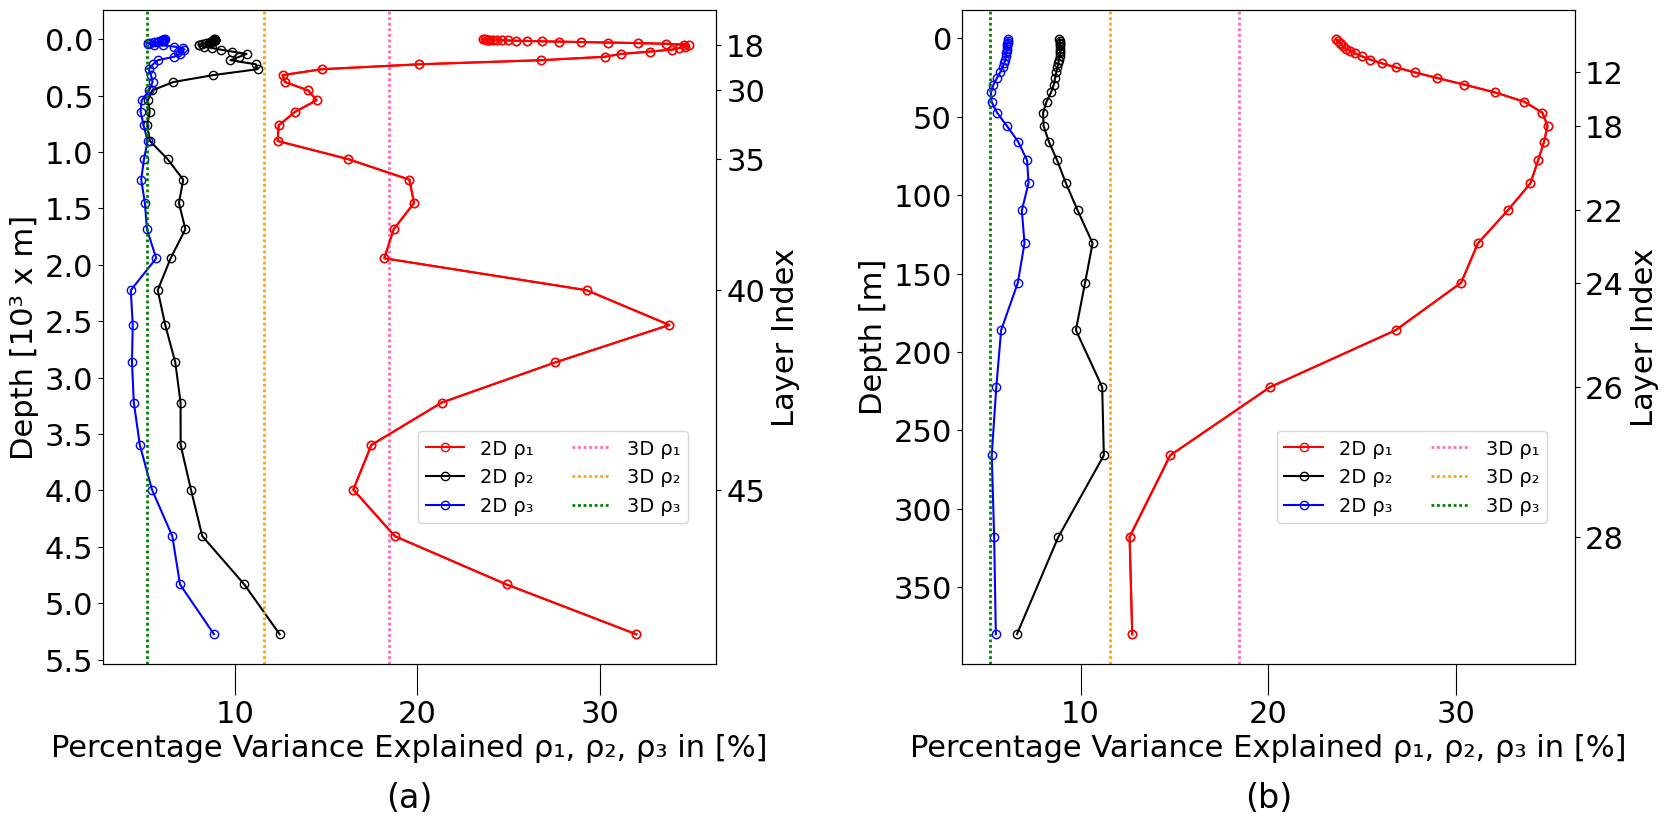

In [7]:

# Create Fig, Ax
fig, ax1 = plt.subplots(1, 2)

# Format 
fig.set_size_inches(19., 8.5)

plt.subplots_adjust(wspace=0.4)

#########################################################################
######## All Depths
#########################################################################


ax1[0].plot(mode1, depthLayer, color21, marker = 'o',markerfacecolor='none', label = label21)
ax1[0].plot(mode2, depthLayer, color22, marker = "o",markerfacecolor='none', label = label22)
ax1[0].plot(mode3, depthLayer, color23, marker = "o",markerfacecolor='none', label = label23)

# Format X axis
ax1[0].set_xlabel("Percentage Variance Explained ρ₁, ρ₂, ρ₃ in [%]", size = label_sz)
ax1[0].tick_params('x',size = tick_sz, labelsize = tick_sz)
#ax1.grid(axis = "x")
ax1[0].axvline(x = percVariance[0], color=color31, label=label31, lw = lineweight, dashes = dashLength)
ax1[0].axvline(x = percVariance[1], color=color32, label=label32, lw = lineweight, dashes = dashLength)
ax1[0].axvline(x = percVariance[2], color=color33, label=label33, lw = lineweight, dashes = dashLength)

# Format Left hand y axis
ax1[0].set_ylabel('Depth [10³ x m]', size =label_sz)
step = 500                            # change this for smaller depth intervals
y_labels = ax1[0].get_yticks()
dep_names = np.arange(0,-y_labels[0],step).astype(int)
dep_names_labels = (dep_names/1000).astype(str).tolist()
ax1[0].set_yticks(-dep_names, dep_names_labels, fontsize = tick_sz)
#ax1[0].axhline(y = 0, color='0.65', linestyle='-', label='', lw = '0.8')

# Create right hand y axis
ax2 = ax1[0].twinx()
ax2.plot(mode1, depthLayer, color21, marker = 'o', markerfacecolor='none')
dep_ind = np.arange(32).astype(str).tolist()



# Select based on depth of plot
#indexLabels = [0, 12, 17, 21, 24, 26, 28, 30]     # first 32
indexLabels = [18, 30, 35, 40, 45]

layerIndex = depthLayer[indexLabels]
ax2.set_yticks(layerIndex, indexLabels, fontsize = tick_sz)
ax2.set_ylabel('Layer Index', size =label_sz)
#ax2.grid(axis = "y")


#########################################################################
######## First 400m
#########################################################################

# ax1[1].plot(mode1[:30], depthLayer[:30,], color21, marker = 'o', label = label21)
# ax1[1].plot(mode2[:30], depthLayer[:30,], color22, marker = 'o', label = label22)
# ax1[1].plot(mode3[:30], depthLayer[:30,], color23, marker = 'o', label = label23)

ax1[1].plot(mode1[:30], depthLayer[:30], color21, marker='o', markerfacecolor='none', label=label21)
ax1[1].plot(mode2[:30], depthLayer[:30], color22, marker='o', markerfacecolor='none', label=label22)
ax1[1].plot(mode3[:30], depthLayer[:30], color23, marker='o', markerfacecolor='none', label=label23)



# Format X axis
ax1[1].set_xlabel("Percentage Variance Explained ρ₁, ρ₂, ρ₃ in [%]", size = label_sz)
ax1[1].tick_params('x',size = tick_sz, labelsize = tick_sz)
#ax1.grid(axis = "x")
ax1[1].axvline(x = percVariance[0], color=color31, label=label31, lw = lineweight, dashes = dashLength)
ax1[1].axvline(x = percVariance[1], color=color32, label=label32, lw = lineweight, dashes = dashLength)
ax1[1].axvline(x = percVariance[2], color=color33, label=label33, lw = lineweight, dashes = dashLength)

# Format Left hand y axis
ax1[1].set_ylabel('Depth [m]', size =label_sz)
step = 50                            # change this for smaller depth intervals
y_labels2 = ax1[1].get_yticks()
dep_names = np.arange(0,-y_labels2[0],step).astype(int)
ax1[1].set_yticks(-dep_names, dep_names.astype(str).tolist(), fontsize = tick_sz)
#ax1[1].axhline(y = 0, color='0.65', linestyle='-', label='', lw = '0.8')

# Create right hand y axis
# Select layers of interest
indexLabels2 =[12, 18, 22, 24, 26, 28]
# Create right hand y-axis
ax3 = ax1[1].twinx()
ax3.set_ylim(ax1[1].get_ylim())
# Plot 
ax3.plot(mode1[:30], depthLayer[0:30], color=color21, marker='o', markerfacecolor='none', label=label21)
dep_ind = np.arange(32).astype(str).tolist()

# Create tick, grid, axis label
layerIndex2 = depthLayer[indexLabels2,]
ax3.set_yticks(layerIndex2, 
               indexLabels2, 
               fontsize = tick_sz)
ax3.set_ylabel('Layer Index', size =label_sz)
#ax3.grid(axis = "y")


#########################################################################
######## Legend and Title
#########################################################################
ax1[0].legend(ncol=2, bbox_to_anchor=(0.97, 0.2), loc='lower right', fontsize=tick_sz-8)
ax1[1].legend(ncol=2, bbox_to_anchor=(0.97, 0.2), loc='lower right', fontsize=tick_sz-8)

#ax1[0].legend(ncol = 2, bbox_to_anchor=(1, .35), fontsize = tick_sz-8)
#ax1[1].legend(ncol = 2, bbox_to_anchor=(1, .35), fontsize = tick_sz-8)


# #fig.suptitle("2D EOF Variance Explained at Depth Layer", size = title_sz)
# ax1[0].set_title("First 3 Eigenvalues for all depths: 5275 m", size = label_sz)
# ax1[1].set_title("First 3 Eigenvalues for top 400 m", size = label_sz)

ax1[0].text(0.5,-0.22, "(a)", size=title_sz, ha="center", 
         transform=ax1[0].transAxes)

ax1[1].text(0.5,-0.22, "(b)", size=title_sz, ha="center", 
         transform=ax1[1].transAxes)

#########################################################################
######## Save Figure
#########################################################################
saveName = 'D:/SCIL/Paper Figs/' + region + '/DJF_Variance_Explained_by_Depth_2_panel_v2.png'
#plt.savefig(saveName, dpi=300, bbox_inches='tight')
plt.show()

# Figure 3

## Read in EOF 1

In [8]:

# EOF Mode of Interest

mode = 1






#################################################################
#### 2D 
#################################################################
# Read in files
fn      = 'EOF_'+str(mode)+'.nc'
fn      = os.path.join(EOF_directory, fn)     # join with EOF path
EOF_ncfile = ds(fn, 'r')
EOF = EOF_ncfile.variables['EOF']
EOF = EOF[:].filled()
EOF_ncfile.close()

# Calculate
area_weight = vol_weight(cut_depths, cut_lon, cut_lat)
EOF = EOF/area_weight  # remember to div by area weight 



# Correct negatively oriented layers by mode

if region == 'Pacific':
    # For Pacific
    noiseLayers1 = [8, 9, 10, 11, 14, 15, 16, 17, 18, 19, 21, 22, 24, 25, 28, 31]
    noiseLayers2 = [0, 4, 5, 9, 11, 14, 15, 16, 18, 20, 23, 25, 26, 27, 29, 30, 31]
    print('pacific')
elif region == "Global":
    noiseLayers1 = [8, 9, 13, 14, 15, 17, 19, 20, 24, 25, 29, 30, 34, 36, 37, 38, 39, 40, 42, 44, 46, 47]
    noiseLayers2 = [3, 4, 5, 6, 8, 11, 12, 13, 15, 17, 18, 20, 21, 22, 24, 26, 28, 30, 31, 33, 35, 41, 45, 46, 47]
    noiseLayers3 = [0, 2, 3, 4, 7, 8, 11, 18, 23, 26, 29, 30, 34, 37, 38, 39, 40, 41, 42, 43, 44, 45, 48]   # Correct
    #noiseLayers3 = [1, 5, 6, 9, 10, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 24, 25, 27, 28, 31, 32, 33, 35, 36, 46, 47]  # Incorrect
    #print(noiseLayers1)

for i in range(depth_end):
    if (i in noiseLayers1) and (mode == 1):
        EOF[i, :, :] = -EOF[i, :, :]
        print("Mode1:")
    elif (i in noiseLayers2) and (mode == 2):
        EOF[i, :, :] = -EOF[i, :, :]
        EOF = -EOF
        print("mode2")
    elif (i in noiseLayers3) and (mode == 3):
        EOF[i, :, :] = -EOF[i, :, :]
        #EOF = -EOF
        print("mode3")



#################################################################
#### 3D 
#################################################################

fn   = 'EOF_'+str(mode)+'.nc'
fn   = os.path.join("F:/GLORYS/cut_EOFs/Winter Avg/Global/", fn)       # join with EOF path
EOF_ncfile = ds(fn, 'r')
EOF3D = EOF_ncfile.variables['EOF']
EOF3D = EOF3D[:].filled()
EOF_ncfile.close()

#area_weight_3D = vol_weight(cut_depths, cut_lon, cut_lat)
EOF3D = EOF3D/area_weight  # remember to div by area weight 

if mode == 1:
    EOF3D = -EOF3D
    depth_list = [0, 18, 24, 27, 29] ## Mode 1
    adjustY = 0.054
elif mode == 2:
    EOF3D = -EOF3D
    depth_list = [0, 18, 24, 26, 28] ## Mode 2
elif mode == 3:
    EOF3D = EOF3D
    #EOF3D = -EOF3D
    depth_list = [0, 16, 21, 22, 27]         ## Mode 3
    adjustY = 0.068

#################################################################
#### Formatting Variable Initialization 
#################################################################


# Plot Formatting
title_sz = 19
label_sz = title_sz-3



#depth = depths[depth_ind]


Mode1:
Mode1:
Mode1:
Mode1:
Mode1:
Mode1:
Mode1:
Mode1:
Mode1:
Mode1:
Mode1:
Mode1:
Mode1:
Mode1:
Mode1:
Mode1:
Mode1:
Mode1:
Mode1:
Mode1:
Mode1:
Mode1:


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl
from mpl_toolkits.basemap import Basemap
from scipy.stats import linregress

# --- Config ---
iz = 0
depth_end = 32
lat_start, lat_end = 960, 1812
lon_start, lon_end = 720, 3492
zlim = 0.000038

lonNum = lon_end/12

# --- Z-limits ---
zlim_left = 0.00009
zlim_right = 0.0003


# --- Slice cube ---


#cube = EOF[:depth_end, lat_start:lat_end, lon_start:lon_end]  # shape: (32, 840, 480)

# 2D EOF
surface = EOF[0, lat_start:lat_end, lon_start:lon_end]
lat_depth = EOF[:depth_end, lat_start, lon_start:lon_end]
lon_depth = EOF[:depth_end, lat_start:lat_end, lon_end]

# 3D EOF
surface3D = EOF3D[0, lat_start:lat_end, lon_start:lon_end]
lat_depth3D = EOF3D[:depth_end, lat_start, lon_start:lon_end]
lon_depth3D = EOF3D[:depth_end, lat_start:lat_end, lon_end]


#depths = np.array(cut_depths[:depth_end])
depths = np.abs(cut_depths[:depth_end])
lats = np.array(cut_lat[lat_start:lat_end])
lons = np.array(cut_lon[lon_start:lon_end])

X, Y, Z = np.meshgrid(lons, lats, -depths)

# --- Clipping and color norm ---


#cube_clipped = np.clip(cube, -zlim, zlim)
norm = mpl.colors.Normalize(vmin=-zlim, vmax=zlim)
# --- Clipping and color norm ---
norm_left = mpl.colors.Normalize(vmin=-zlim_left, vmax=zlim_left)
norm_right = mpl.colors.Normalize(vmin=-zlim_right, vmax=zlim_right)


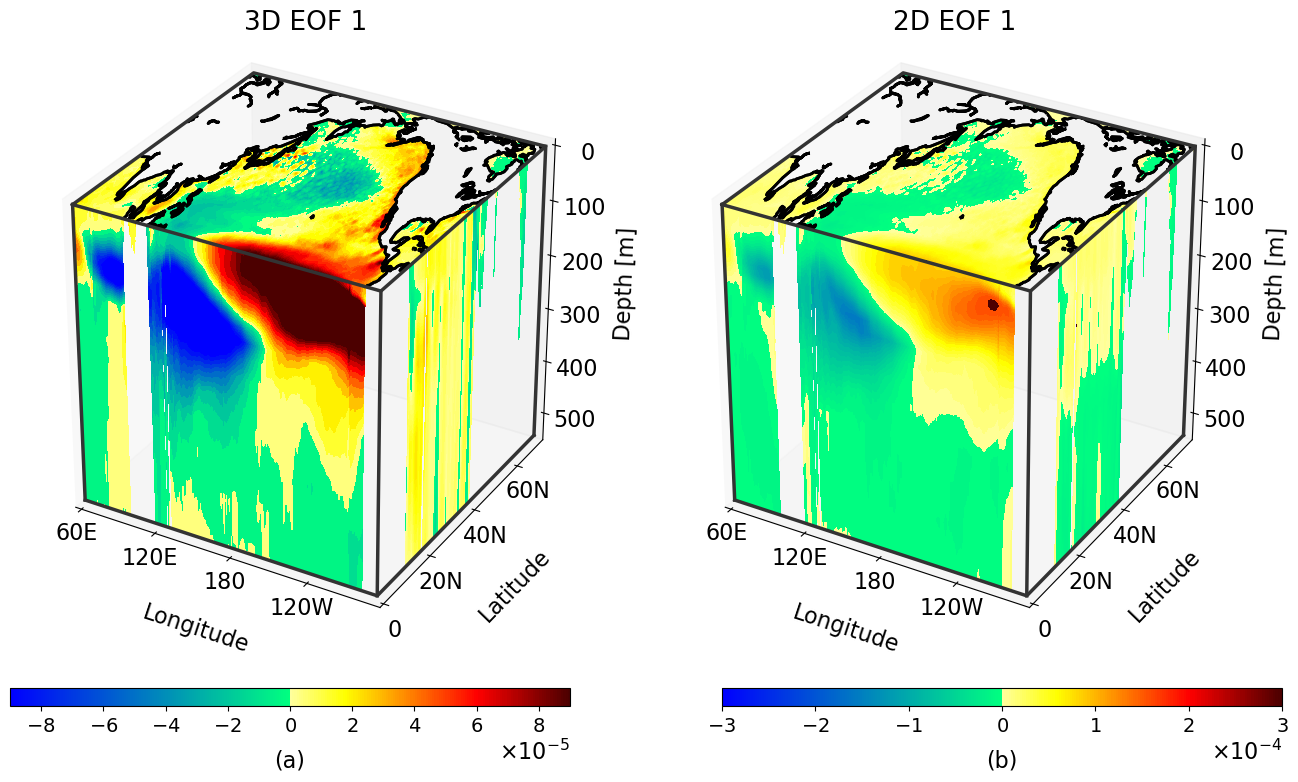

In [10]:
# --- Setup Figure ---
fig = plt.figure(figsize=(16, 9))
plt.subplots_adjust(wspace=0.1)
levels = 50

# --- Tick Configuration ---
lon_ticks   = np.arange(60, lonNum, 60)
lat_ticks   = np.arange(0, 81, 20)
depth_ticks = np.arange(0, depths.max() + 1, 100)

# --- Z-limits ---
# zlim_left = 0.0003
# zlim_right = 0.00009

# --- Clipping and color norm ---


# norm_left = mpl.colors.Normalize(vmin=-zlim_left, vmax=zlim_left)
# norm_right = mpl.colors.Normalize(vmin=-zlim_right, vmax=zlim_right)

# --- Plot Helper Function ---
def configure_3d_axes(ax, xticks, yticks, zticks, title):
    ax.grid(False)
    ax.set_xticks(xticks, labels=[format_longitude(int(l)) for l in xticks], fontsize=label_sz)
    ax.set_yticks(yticks, labels=[format_latitude(int(l)) for l in yticks], fontsize=label_sz)
    ax.set_zticks(-zticks, labels=[f"{t:.0f}" for t in zticks], fontsize=label_sz)
    ax.tick_params(axis='x', pad=-2, labelsize=label_sz)
    ax.tick_params(axis='y', pad=0,  labelsize=label_sz)
    ax.tick_params(axis='z', pad=7,  labelsize=label_sz)
    ax.set_xlabel('Longitude', fontsize=label_sz, labelpad=13)
    ax.set_ylabel('Latitude', fontsize=label_sz, labelpad=16)
    ax.set_zlabel('Depth [m]', fontsize=label_sz, labelpad=16, rotation=0)
    ax.set_title(title, fontsize=title_sz)
    ax.set_xlim(lons.min(), lons.max())
    ax.set_ylim(lats.min(), lats.max())
    ax.set_zlim(-depths.max(), 0)
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=30, azim=-60)

    # Box edges
    xmin, xmax = lons.min(), lons.max()
    ymin, ymax = lats.min(), lats.max()
    zmin, zmax = -depths.max(), 0
    edges_kw = dict(color='0.2', linewidth=2.5, zorder=100)

    ax.plot([xmin, xmax, xmax], [ymin, ymin, ymax], [zmin]*3, **edges_kw)
    ax.plot([xmin, xmax, xmax, xmin, xmin], [ymin, ymin, ymax, ymax, ymin], [zmax]*5, **edges_kw)
    for x in (xmin, xmax):
        for y in (ymin, ymax):
            if not (x == xmin and y == ymax):  # skip back-left
                ax.plot([x, x], [y, y], [zmin, zmax], **edges_kw)

# === 3D EOF Plot (Left) ===
ax2 = fig.add_subplot(121, projection='3d')

cs2 = ax2.contourf(X[:, :, 0], Y[:, :, 0], surface3D, zdir='z', offset=-depths[iz],
                   levels=levels, cmap=newcmp2, norm=norm_left, alpha=1, extend='both', vmin=-zlim_left, vmax=zlim_left)
ax2.contourf(X[0, :, :], lat_depth3D.T, Z[0, :, :], zdir='y', levels=levels, cmap=newcmp2,
             norm=norm_left, alpha=1, vmin=-zlim_left, vmax=zlim_left, extend='both')
ax2.contourf(lon_depth3D.T, Y[:, -1, :], Z[:, -1, :], zdir='x', offset=lonNum, levels=levels,
             cmap=newcmp2, norm=norm_left, alpha=1, vmin=-zlim_left, vmax=zlim_left, extend='both')

m2 = Basemap(projection='cyl', llcrnrlon=lons.min(), urcrnrlon=lons.max(),
             llcrnrlat=lats.min(), urcrnrlat=lats.max())
ax2.add_collection3d(m2.drawcoastlines(linewidth=2), zs=-depths[iz], zdir='z')

configure_3d_axes(ax2, lon_ticks, lat_ticks, depth_ticks, f"3D EOF {mode}")
#ax2.text2D(0.02, 0.95, "(a)", transform=ax2.transAxes, fontsize=18, fontweight='bold')

# === 2D EOF Plot (Right) ===
ax = fig.add_subplot(122, projection='3d')

cs = ax.contourf(X[:, :, 0], Y[:, :, 0], surface, zdir='z', offset=-depths[iz],
                 levels=levels, cmap=newcmp2, norm=norm_right, alpha=1, extend='both', vmin=-zlim_right, vmax=zlim_right)
ax.contourf(X[0, :, :], lat_depth.T, Z[0, :, :], zdir='y', levels=levels,
            cmap=newcmp2, norm=norm_right, alpha=1, vmin=-zlim_right, vmax=zlim_right, extend='both')
ax.contourf(lon_depth.T, Y[:, -1, :], Z[:, -1, :], zdir='x', offset=lonNum, levels=levels,
            cmap=newcmp2, norm=norm_right, alpha=1, vmin=-zlim_right, vmax=zlim_right, extend='both')

m = Basemap(projection='cyl', llcrnrlon=lons.min(), urcrnrlon=lons.max(),
            llcrnrlat=lats.min(), urcrnrlat=lats.max())
ax.add_collection3d(m.drawcoastlines(linewidth=2), zs=-depths[iz], zdir='z')

configure_3d_axes(ax, lon_ticks, lat_ticks, depth_ticks, f"2D EOF {mode}")
# ax.text2D(0.02, 0.95, "(b)", transform=ax.transAxes, fontsize=18, fontweight='bold')

# === Separate Colorbars BELOW the plots ===

# Left colorbar (under left plot)
sm_left = mpl.cm.ScalarMappable(norm=norm_left, cmap=newcmp2)
sm_left.set_array([])
cbar_ax_left = fig.add_axes([0.125, 0.08, 0.35, 0.02])  # [left, bottom, width, height]
cbar_left = fig.colorbar(sm_left, cax=cbar_ax_left, orientation='horizontal',
                         format=mpl.ticker.ScalarFormatter(useMathText=True))
cbar_left.ax.tick_params(labelsize=14, direction='out')
cbar_left.ax.xaxis.get_offset_text().set_fontsize(label_sz)
cbar_left.formatter.set_powerlimits((0, 0))
cbar_left.update_ticks()
cbar_left.set_label("(a)", fontsize=16, labelpad=10, loc='center')

# Right colorbar (under right plot)
sm_right = mpl.cm.ScalarMappable(norm=norm_right, cmap=newcmp2)
sm_right.set_array([])
cbar_ax_right = fig.add_axes([0.57, 0.08, 0.35, 0.02])  # [left, bottom, width, height]
cbar_right = fig.colorbar(sm_right, cax=cbar_ax_right, orientation='horizontal',
                          format=mpl.ticker.ScalarFormatter(useMathText=True))
cbar_right.ax.tick_params(labelsize=14, direction='out')
cbar_right.ax.xaxis.get_offset_text().set_fontsize(label_sz)
cbar_right.formatter.set_powerlimits((0, 0))
cbar_right.update_ticks()
cbar_right.set_label("(b)", fontsize=16, labelpad=10, loc='center')

# --- Show Plot ---
saveName = "D:/SCIL/Paper Figs/" + region + "/Cross Sections/Cube_" + region + "_mode_" + str(mode)
#plt.savefig(saveName, bbox_inches='tight', dpi = 700)
plt.show()


# Figure 4

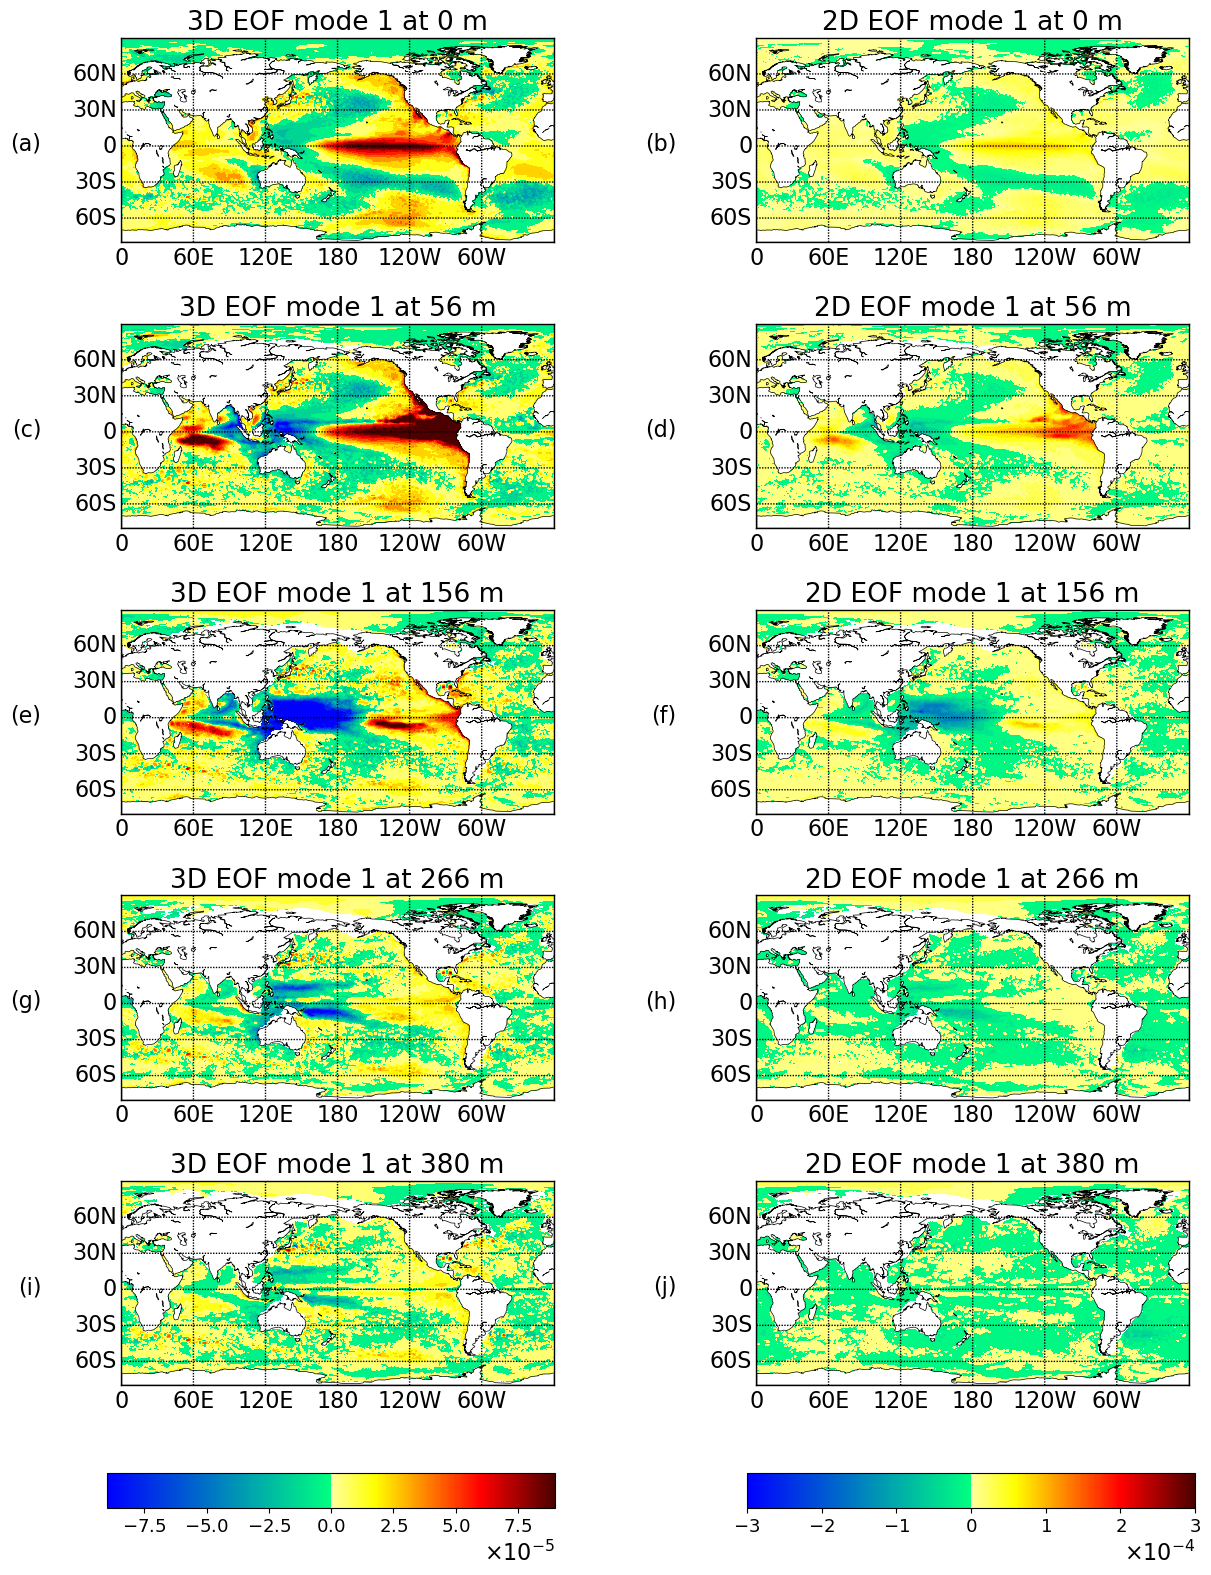

Figure saved to: D:/SCIL/Paper Figs/Global/eof1/EOF_panels_0_18_24_27_29.png


In [11]:
def plot_static_depth_panels(depth_indexes):
    clip2D = 0.0003
    clip3D = 0.00009
    n_panels = len(depth_indexes)

    fig, axes = plt.subplots(n_panels, 2, figsize=(16, 3.5 * n_panels))
    plt.subplots_adjust(wspace=0.05, hspace=0.4)

    norm3D = mpl.colors.Normalize(vmin=-clip3D, vmax=clip3D)
    norm2D = mpl.colors.Normalize(vmin=-clip2D, vmax=clip2D)

    # For labeling panels with (a), (b), ...
    panel_labels = list(string.ascii_lowercase)

    for i, dp in enumerate(depth_indexes):
        if dp >= len(depths):
            print(f"Depth index {dp} out of bounds — skipping.")
            continue

        str_depth = f"{dp:02d}"
        depth = depths[dp]

        dat3D = np.clip(EOF3D[dp, :, :], -clip3D, clip3D)
        dat2D = np.clip(EOF[dp, :, :], -clip2D, clip2D)

        ax3D = axes[i, 0]
        ax2D = axes[i, 1]

        # === 3D Plot ===
        map3D = Basemap(projection='cyl',
                        llcrnrlat=cut_lat[0], urcrnrlat=cut_lat[-1],
                        llcrnrlon=cut_lon[0], urcrnrlon=cut_lon[-1],
                        resolution='c', ax=ax3D)
        map3D.drawcoastlines(color='black', linewidth=0.5)
        map3D.drawmapboundary()
        map3D.drawparallels(np.arange(cut_lat[0]+20, cut_lat[-1], 30),
                            labels=[1, 0, 0, 0], fmt=format_latitude, fontsize=label_sz)
        map3D.drawmeridians(np.arange(cut_lon[0], cut_lon[-1], 60),
                            labels=[0, 0, 0, 1], fmt=format_longitude, fontsize=label_sz)

        ax3D.contourf(cut_lon, cut_lat, dat3D, 20, cmap=newcmp2, norm=norm3D)
        ax3D.set_title(f"3D EOF mode {mode} at {round(depth)} m", size=title_sz)

        # === 2D Plot ===
        map2D = Basemap(projection='cyl',
                        llcrnrlat=cut_lat[0], urcrnrlat=cut_lat[-1],
                        llcrnrlon=cut_lon[0], urcrnrlon=cut_lon[-1],
                        resolution='c', ax=ax2D)
        map2D.drawcoastlines(color='black', linewidth=0.5)
        map2D.drawmapboundary()
        map2D.drawparallels(np.arange(cut_lat[0]+20, cut_lat[-1], 30),
                            labels=[1, 0, 0, 0], fmt=format_latitude, fontsize=label_sz)
        map2D.drawmeridians(np.arange(cut_lon[0], cut_lon[-1], 60),
                            labels=[0, 0, 0, 1], fmt=format_longitude, fontsize=label_sz)

        ax2D.contourf(cut_lon, cut_lat, dat2D, 20, cmap=newcmp2, norm=norm2D)
        ax2D.set_title(f"2D EOF mode {mode} at {round(depth)} m", size=title_sz)

        # === Panel Labels Outside Plots ===
        # Get position of current axes in figure coordinates
        for j, ax in enumerate([ax3D, ax2D]):
            label = f"({panel_labels[i * 2 + j]})"
            bbox = ax.get_position()
            # Place label to the left of the y-axis tick labels
            fig.text(bbox.x0 - 0.05, bbox.y1 - 0.054, label,
                     fontsize=label_sz, va='top', ha='right')

    # === Shared Colorbars (Bottom of Columns) ===
    cbar_ax3D = fig.add_axes([0.17, 0.04, 0.28, 0.02])  # [left, bottom, width, height]
    sm3D = mpl.cm.ScalarMappable(norm=norm3D, cmap=newcmp2)
    sm3D.set_array([])
    cbar3D = fig.colorbar(sm3D, cax=cbar_ax3D, orientation='horizontal',
                          format=mpl.ticker.ScalarFormatter(useMathText=True))
    cbar3D.ax.tick_params(labelsize=13)
    cbar3D.ax.xaxis.get_offset_text().set_fontsize(label_sz)
    cbar3D.formatter.set_powerlimits((0, 0))
    cbar3D.update_ticks()
    #cbar3D.set_label("3D EOF amplitude", fontsize=12)

    cbar_ax2D = fig.add_axes([0.57, 0.04, 0.28, 0.02])
    sm2D = mpl.cm.ScalarMappable(norm=norm2D, cmap=newcmp2)
    sm2D.set_array([])
    cbar2D = fig.colorbar(sm2D, cax=cbar_ax2D, orientation='horizontal',
                          format=mpl.ticker.ScalarFormatter(useMathText=True))
    cbar2D.ax.tick_params(labelsize=13)
    cbar2D.ax.xaxis.get_offset_text().set_fontsize(label_sz)
    cbar2D.formatter.set_powerlimits((0, 0))
    cbar2D.update_ticks()
    #cbar2D.set_label("2D EOF amplitude", fontsize=12)

    # Save figure to PNG
    output_path = f"D:/SCIL/Paper Figs/{region}/eof{mode}/EOF_panels_{'_'.join(map(str, depth_indexes))}.png" 
    #plt.savefig(output_path, bbox_inches='tight', dpi=700)
    plt.show()
    print(f"Figure saved to: {output_path}")



# === Call the function with your depth indexes ===

plot_static_depth_panels(depth_list)


# Figure 5

## Read in EOF 2

In [12]:

# EOF Mode of Interest

mode = 2

#################################################################
#### 2D 
#################################################################
# Read in files
fn      = 'EOF_'+str(mode)+'.nc'
fn      = os.path.join(EOF_directory, fn)     # join with EOF path
EOF_ncfile = ds(fn, 'r')
EOF = EOF_ncfile.variables['EOF']
EOF = EOF[:].filled()
EOF_ncfile.close()

# Calculate
area_weight = vol_weight(cut_depths, cut_lon, cut_lat)
EOF = EOF/area_weight  # remember to div by area weight 

# Correct negatively oriented layers by mode

if region == 'Pacific':
    # For Pacific
    noiseLayers1 = [8, 9, 10, 11, 14, 15, 16, 17, 18, 19, 21, 22, 24, 25, 28, 31]
    noiseLayers2 = [0, 4, 5, 9, 11, 14, 15, 16, 18, 20, 23, 25, 26, 27, 29, 30, 31]
    print('pacific')
elif region == "Global":
    noiseLayers1 = [8, 9, 13, 14, 15, 17, 19, 20, 24, 25, 29, 30, 34, 36, 37, 38, 39, 40, 42, 44, 46, 47]
    noiseLayers2 = [3, 4, 5, 6, 8, 11, 12, 13, 15, 17, 18, 20, 21, 22, 24, 26, 28, 30, 31, 33, 35, 41, 45, 46, 47]
    noiseLayers3 = [0, 2, 3, 4, 7, 8, 11, 18, 23, 26, 29, 30, 34, 37, 38, 39, 40, 41, 42, 43, 44, 45, 48]   # Correct
    #noiseLayers3 = [1, 5, 6, 9, 10, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 24, 25, 27, 28, 31, 32, 33, 35, 36, 46, 47]  # Incorrect
    #print(noiseLayers1)

for i in range(depth_end):
    if (i in noiseLayers1) and (mode == 1):
        EOF[i, :, :] = -EOF[i, :, :]
        print("Mode1:")
    elif (i in noiseLayers2) and (mode == 2):
        EOF[i, :, :] = -EOF[i, :, :]
        EOF = -EOF
        print("mode2")
    elif (i in noiseLayers3) and (mode == 3):
        EOF[i, :, :] = -EOF[i, :, :]
        #EOF = -EOF
        print("mode3")



#################################################################
#### 3D 
#################################################################

fn   = 'EOF_'+str(mode)+'.nc'
fn   = os.path.join("F:/GLORYS/cut_EOFs/Winter Avg/Global/", fn)       # join with EOF path
EOF_ncfile = ds(fn, 'r')
EOF3D = EOF_ncfile.variables['EOF']
EOF3D = EOF3D[:].filled()
EOF_ncfile.close()

#area_weight_3D = vol_weight(cut_depths, cut_lon, cut_lat)
EOF3D = EOF3D/area_weight  # remember to div by area weight 

if mode == 1:
    EOF3D = -EOF3D
    depth_list = [0, 18, 24, 27, 29] ## Mode 1
    adjustY = 0.054
elif mode == 2:
    EOF3D = -EOF3D
    depth_list = [0, 18, 24, 26, 28] ## Mode 2
elif mode == 3:
    EOF3D = EOF3D
    #EOF3D = -EOF3D
    depth_list = [0, 16, 21, 22, 27]         ## Mode 3
    adjustY = 0.068

#################################################################
#### Formatting Variable Initialization 
#################################################################


# Plot Formatting
title_sz = 19
label_sz = title_sz-3



#depth = depths[depth_ind]


mode2
mode2
mode2
mode2
mode2
mode2
mode2
mode2
mode2
mode2
mode2
mode2
mode2
mode2
mode2
mode2
mode2
mode2
mode2


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl
from mpl_toolkits.basemap import Basemap
from scipy.stats import linregress

# --- Config ---
iz = 0
depth_end = 32
lat_start, lat_end = 960, 1812
lon_start, lon_end = 720, 3492
zlim = 0.000038

lonNum = lon_end/12

# --- Z-limits ---
zlim_left = 0.00009
zlim_right = 0.0003


# --- Slice cube ---


#cube = EOF[:depth_end, lat_start:lat_end, lon_start:lon_end]  # shape: (32, 840, 480)

# 2D EOF
surface = EOF[0, lat_start:lat_end, lon_start:lon_end]
lat_depth = EOF[:depth_end, lat_start, lon_start:lon_end]
lon_depth = EOF[:depth_end, lat_start:lat_end, lon_end]

# 3D EOF
surface3D = EOF3D[0, lat_start:lat_end, lon_start:lon_end]
lat_depth3D = EOF3D[:depth_end, lat_start, lon_start:lon_end]
lon_depth3D = EOF3D[:depth_end, lat_start:lat_end, lon_end]


#depths = np.array(cut_depths[:depth_end])
depths = np.abs(cut_depths[:depth_end])
lats = np.array(cut_lat[lat_start:lat_end])
lons = np.array(cut_lon[lon_start:lon_end])

X, Y, Z = np.meshgrid(lons, lats, -depths)

# --- Clipping and color norm ---


#cube_clipped = np.clip(cube, -zlim, zlim)
norm = mpl.colors.Normalize(vmin=-zlim, vmax=zlim)
# --- Clipping and color norm ---
norm_left = mpl.colors.Normalize(vmin=-zlim_left, vmax=zlim_left)
norm_right = mpl.colors.Normalize(vmin=-zlim_right, vmax=zlim_right)


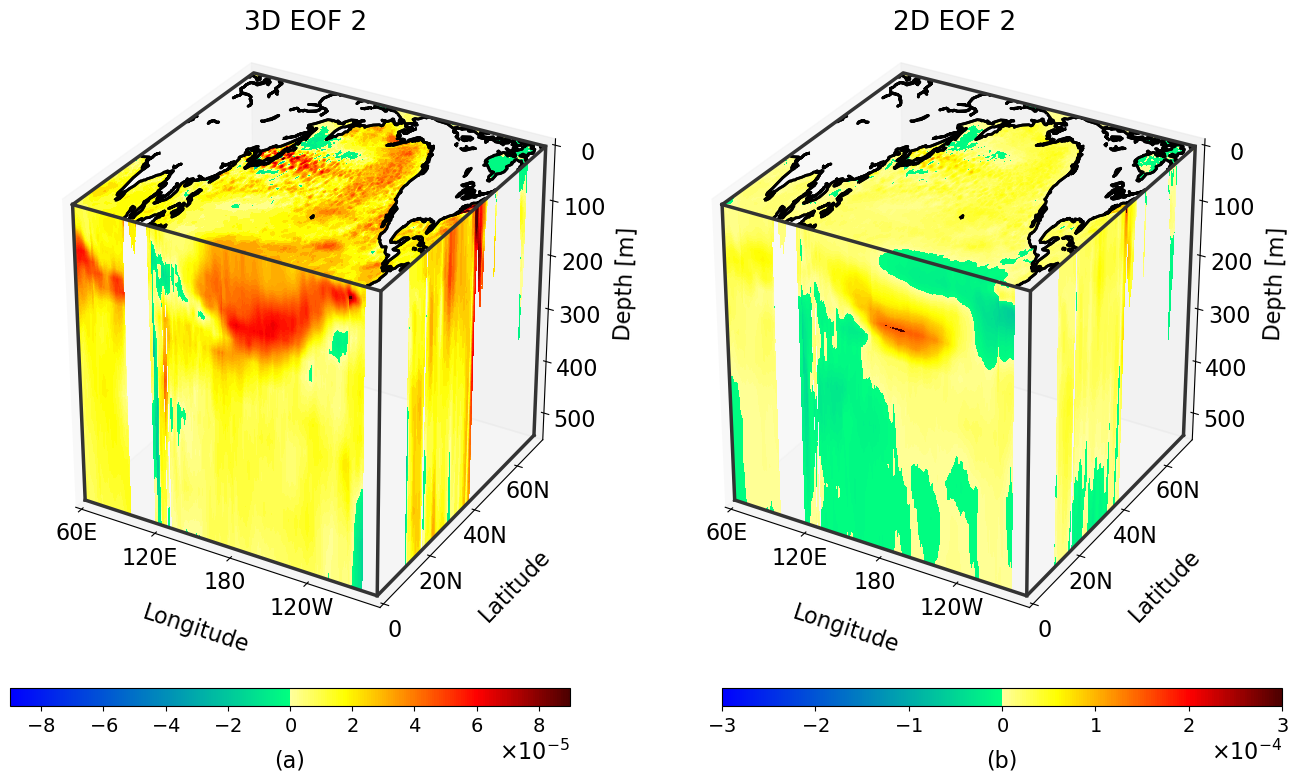

In [14]:
# --- Setup Figure ---
fig = plt.figure(figsize=(16, 9))
plt.subplots_adjust(wspace=0.1)
levels = 50

# --- Tick Configuration ---
lon_ticks   = np.arange(60, lonNum, 60)
lat_ticks   = np.arange(0, 81, 20)
depth_ticks = np.arange(0, depths.max() + 1, 100)

# --- Z-limits ---
# zlim_left = 0.0003
# zlim_right = 0.00009

# --- Clipping and color norm ---


# norm_left = mpl.colors.Normalize(vmin=-zlim_left, vmax=zlim_left)
# norm_right = mpl.colors.Normalize(vmin=-zlim_right, vmax=zlim_right)

# --- Plot Helper Function ---
def configure_3d_axes(ax, xticks, yticks, zticks, title):
    ax.grid(False)
    ax.set_xticks(xticks, labels=[format_longitude(int(l)) for l in xticks], fontsize=label_sz)
    ax.set_yticks(yticks, labels=[format_latitude(int(l)) for l in yticks], fontsize=label_sz)
    ax.set_zticks(-zticks, labels=[f"{t:.0f}" for t in zticks], fontsize=label_sz)
    ax.tick_params(axis='x', pad=-2, labelsize=label_sz)
    ax.tick_params(axis='y', pad=0,  labelsize=label_sz)
    ax.tick_params(axis='z', pad=7,  labelsize=label_sz)
    ax.set_xlabel('Longitude', fontsize=label_sz, labelpad=13)
    ax.set_ylabel('Latitude', fontsize=label_sz, labelpad=16)
    ax.set_zlabel('Depth [m]', fontsize=label_sz, labelpad=16, rotation=0)
    ax.set_title(title, fontsize=title_sz)
    ax.set_xlim(lons.min(), lons.max())
    ax.set_ylim(lats.min(), lats.max())
    ax.set_zlim(-depths.max(), 0)
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=30, azim=-60)

    # Box edges
    xmin, xmax = lons.min(), lons.max()
    ymin, ymax = lats.min(), lats.max()
    zmin, zmax = -depths.max(), 0
    edges_kw = dict(color='0.2', linewidth=2.5, zorder=100)

    ax.plot([xmin, xmax, xmax], [ymin, ymin, ymax], [zmin]*3, **edges_kw)
    ax.plot([xmin, xmax, xmax, xmin, xmin], [ymin, ymin, ymax, ymax, ymin], [zmax]*5, **edges_kw)
    for x in (xmin, xmax):
        for y in (ymin, ymax):
            if not (x == xmin and y == ymax):  # skip back-left
                ax.plot([x, x], [y, y], [zmin, zmax], **edges_kw)

# === 3D EOF Plot (Left) ===
ax2 = fig.add_subplot(121, projection='3d')

cs2 = ax2.contourf(X[:, :, 0], Y[:, :, 0], surface3D, zdir='z', offset=-depths[iz],
                   levels=levels, cmap=newcmp2, norm=norm_left, alpha=1, extend='both', vmin=-zlim_left, vmax=zlim_left)
ax2.contourf(X[0, :, :], lat_depth3D.T, Z[0, :, :], zdir='y', levels=levels, cmap=newcmp2,
             norm=norm_left, alpha=1, vmin=-zlim_left, vmax=zlim_left, extend='both')
ax2.contourf(lon_depth3D.T, Y[:, -1, :], Z[:, -1, :], zdir='x', offset=lonNum, levels=levels,
             cmap=newcmp2, norm=norm_left, alpha=1, vmin=-zlim_left, vmax=zlim_left, extend='both')

m2 = Basemap(projection='cyl', llcrnrlon=lons.min(), urcrnrlon=lons.max(),
             llcrnrlat=lats.min(), urcrnrlat=lats.max())
ax2.add_collection3d(m2.drawcoastlines(linewidth=2), zs=-depths[iz], zdir='z')

configure_3d_axes(ax2, lon_ticks, lat_ticks, depth_ticks, f"3D EOF {mode}")
#ax2.text2D(0.02, 0.95, "(a)", transform=ax2.transAxes, fontsize=18, fontweight='bold')

# === 2D EOF Plot (Right) ===
ax = fig.add_subplot(122, projection='3d')

cs = ax.contourf(X[:, :, 0], Y[:, :, 0], surface, zdir='z', offset=-depths[iz],
                 levels=levels, cmap=newcmp2, norm=norm_right, alpha=1, extend='both', vmin=-zlim_right, vmax=zlim_right)
ax.contourf(X[0, :, :], lat_depth.T, Z[0, :, :], zdir='y', levels=levels,
            cmap=newcmp2, norm=norm_right, alpha=1, vmin=-zlim_right, vmax=zlim_right, extend='both')
ax.contourf(lon_depth.T, Y[:, -1, :], Z[:, -1, :], zdir='x', offset=lonNum, levels=levels,
            cmap=newcmp2, norm=norm_right, alpha=1, vmin=-zlim_right, vmax=zlim_right, extend='both')

m = Basemap(projection='cyl', llcrnrlon=lons.min(), urcrnrlon=lons.max(),
            llcrnrlat=lats.min(), urcrnrlat=lats.max())
ax.add_collection3d(m.drawcoastlines(linewidth=2), zs=-depths[iz], zdir='z')

configure_3d_axes(ax, lon_ticks, lat_ticks, depth_ticks, f"2D EOF {mode}")
# ax.text2D(0.02, 0.95, "(b)", transform=ax.transAxes, fontsize=18, fontweight='bold')

# === Separate Colorbars BELOW the plots ===

# Left colorbar (under left plot)
sm_left = mpl.cm.ScalarMappable(norm=norm_left, cmap=newcmp2)
sm_left.set_array([])
cbar_ax_left = fig.add_axes([0.125, 0.08, 0.35, 0.02])  # [left, bottom, width, height]
cbar_left = fig.colorbar(sm_left, cax=cbar_ax_left, orientation='horizontal',
                         format=mpl.ticker.ScalarFormatter(useMathText=True))
cbar_left.ax.tick_params(labelsize=14, direction='out')
cbar_left.ax.xaxis.get_offset_text().set_fontsize(label_sz)
cbar_left.formatter.set_powerlimits((0, 0))
cbar_left.update_ticks()
cbar_left.set_label("(a)", fontsize=16, labelpad=10, loc='center')

# Right colorbar (under right plot)
sm_right = mpl.cm.ScalarMappable(norm=norm_right, cmap=newcmp2)
sm_right.set_array([])
cbar_ax_right = fig.add_axes([0.57, 0.08, 0.35, 0.02])  # [left, bottom, width, height]
cbar_right = fig.colorbar(sm_right, cax=cbar_ax_right, orientation='horizontal',
                          format=mpl.ticker.ScalarFormatter(useMathText=True))
cbar_right.ax.tick_params(labelsize=14, direction='out')
cbar_right.ax.xaxis.get_offset_text().set_fontsize(label_sz)
cbar_right.formatter.set_powerlimits((0, 0))
cbar_right.update_ticks()
cbar_right.set_label("(b)", fontsize=16, labelpad=10, loc='center')

# --- Show Plot ---
saveName = "D:/SCIL/Paper Figs/" + region + "/Cross Sections/Cube_" + region + "_mode_" + str(mode)
#plt.savefig(saveName, bbox_inches='tight', dpi = 700)
plt.show()


# Figure 6

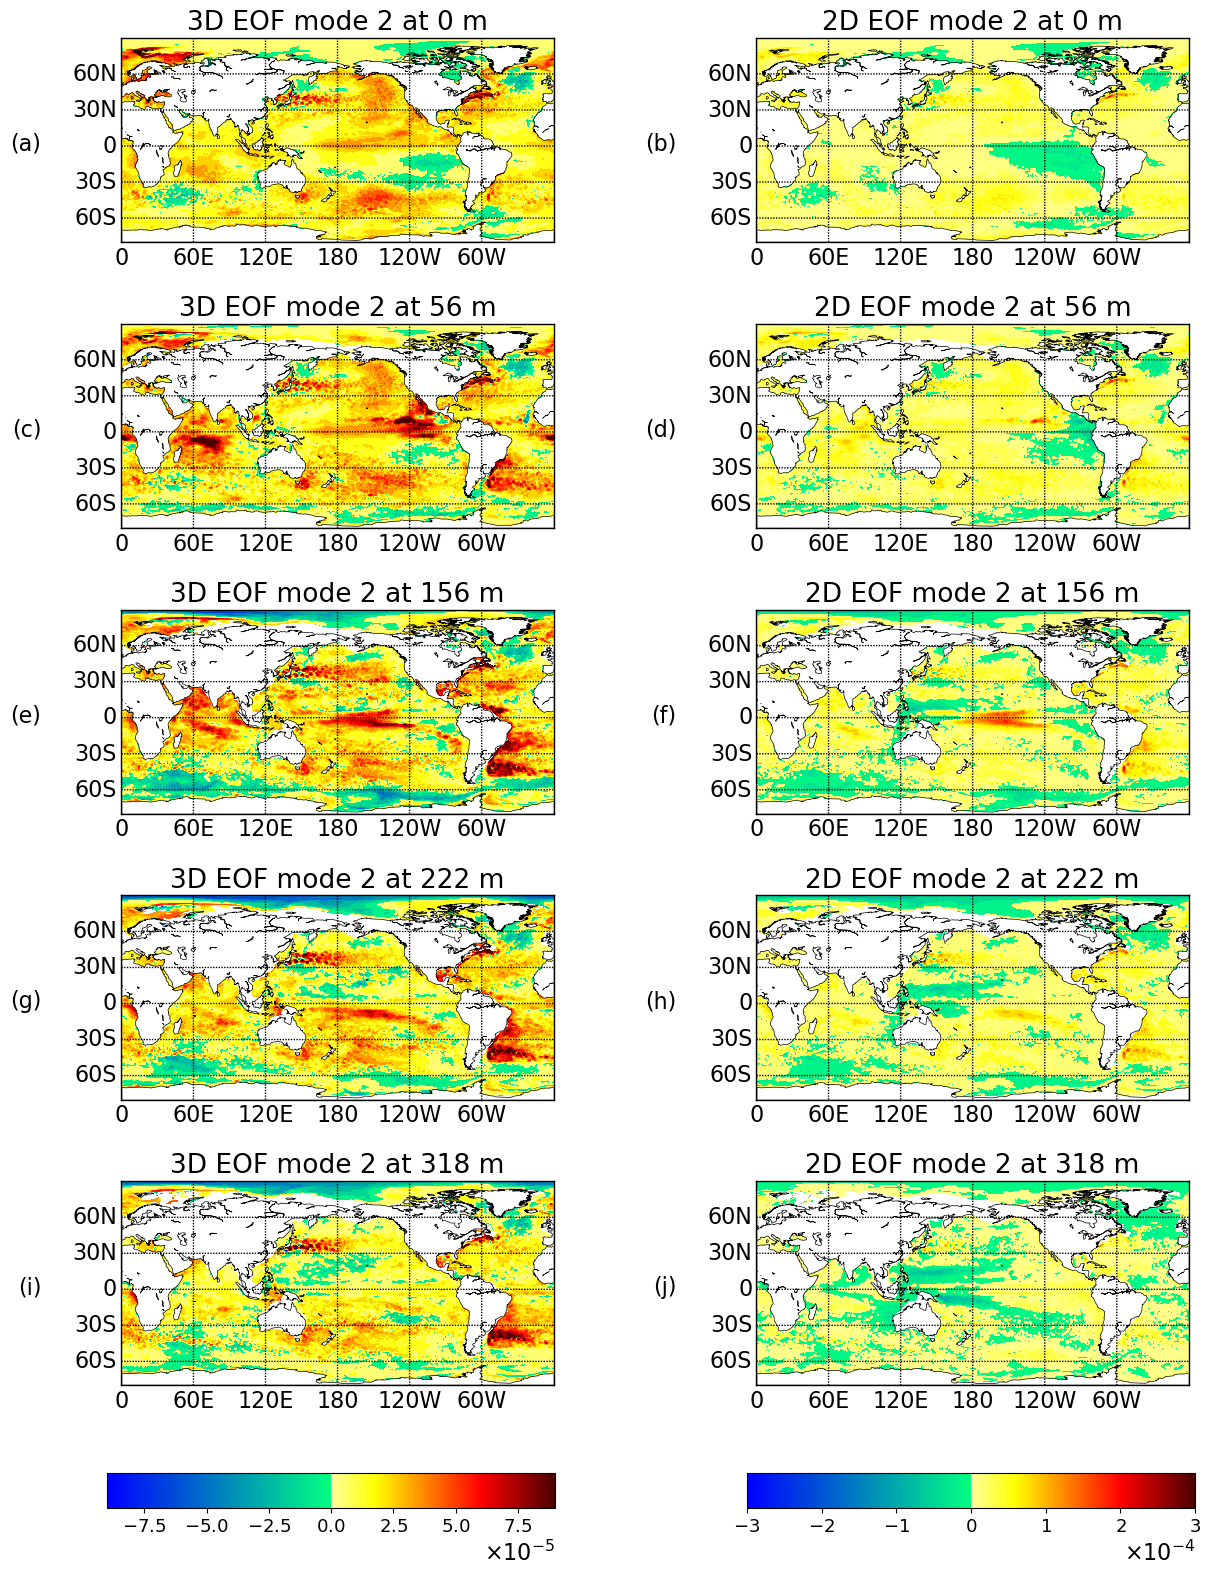

Figure saved to: D:/SCIL/Paper Figs/Global/eof2/EOF_panels_0_18_24_26_28.png


In [15]:
def plot_static_depth_panels(depth_indexes):
    clip2D = 0.0003
    clip3D = 0.00009
    n_panels = len(depth_indexes)

    fig, axes = plt.subplots(n_panels, 2, figsize=(16, 3.5 * n_panels))
    plt.subplots_adjust(wspace=0.05, hspace=0.4)

    norm3D = mpl.colors.Normalize(vmin=-clip3D, vmax=clip3D)
    norm2D = mpl.colors.Normalize(vmin=-clip2D, vmax=clip2D)

    # For labeling panels with (a), (b), ...
    panel_labels = list(string.ascii_lowercase)

    for i, dp in enumerate(depth_indexes):
        if dp >= len(depths):
            print(f"Depth index {dp} out of bounds — skipping.")
            continue

        str_depth = f"{dp:02d}"
        depth = depths[dp]

        dat3D = np.clip(EOF3D[dp, :, :], -clip3D, clip3D)
        dat2D = np.clip(EOF[dp, :, :], -clip2D, clip2D)

        ax3D = axes[i, 0]
        ax2D = axes[i, 1]

        # === 3D Plot ===
        map3D = Basemap(projection='cyl',
                        llcrnrlat=cut_lat[0], urcrnrlat=cut_lat[-1],
                        llcrnrlon=cut_lon[0], urcrnrlon=cut_lon[-1],
                        resolution='c', ax=ax3D)
        map3D.drawcoastlines(color='black', linewidth=0.5)
        map3D.drawmapboundary()
        map3D.drawparallels(np.arange(cut_lat[0]+20, cut_lat[-1], 30),
                            labels=[1, 0, 0, 0], fmt=format_latitude, fontsize=label_sz)
        map3D.drawmeridians(np.arange(cut_lon[0], cut_lon[-1], 60),
                            labels=[0, 0, 0, 1], fmt=format_longitude, fontsize=label_sz)

        ax3D.contourf(cut_lon, cut_lat, dat3D, 20, cmap=newcmp2, norm=norm3D)
        ax3D.set_title(f"3D EOF mode {mode} at {round(depth)} m", size=title_sz)

        # === 2D Plot ===
        map2D = Basemap(projection='cyl',
                        llcrnrlat=cut_lat[0], urcrnrlat=cut_lat[-1],
                        llcrnrlon=cut_lon[0], urcrnrlon=cut_lon[-1],
                        resolution='c', ax=ax2D)
        map2D.drawcoastlines(color='black', linewidth=0.5)
        map2D.drawmapboundary()
        map2D.drawparallels(np.arange(cut_lat[0]+20, cut_lat[-1], 30),
                            labels=[1, 0, 0, 0], fmt=format_latitude, fontsize=label_sz)
        map2D.drawmeridians(np.arange(cut_lon[0], cut_lon[-1], 60),
                            labels=[0, 0, 0, 1], fmt=format_longitude, fontsize=label_sz)

        ax2D.contourf(cut_lon, cut_lat, dat2D, 20, cmap=newcmp2, norm=norm2D)
        ax2D.set_title(f"2D EOF mode {mode} at {round(depth)} m", size=title_sz)

        # === Panel Labels Outside Plots ===
        # Get position of current axes in figure coordinates
        for j, ax in enumerate([ax3D, ax2D]):
            label = f"({panel_labels[i * 2 + j]})"
            bbox = ax.get_position()
            # Place label to the left of the y-axis tick labels
            fig.text(bbox.x0 - 0.05, bbox.y1 - 0.054, label,
                     fontsize=label_sz, va='top', ha='right')

    # === Shared Colorbars (Bottom of Columns) ===
    cbar_ax3D = fig.add_axes([0.17, 0.04, 0.28, 0.02])  # [left, bottom, width, height]
    sm3D = mpl.cm.ScalarMappable(norm=norm3D, cmap=newcmp2)
    sm3D.set_array([])
    cbar3D = fig.colorbar(sm3D, cax=cbar_ax3D, orientation='horizontal',
                          format=mpl.ticker.ScalarFormatter(useMathText=True))
    cbar3D.ax.tick_params(labelsize=13)
    cbar3D.ax.xaxis.get_offset_text().set_fontsize(label_sz)
    cbar3D.formatter.set_powerlimits((0, 0))
    cbar3D.update_ticks()
    #cbar3D.set_label("3D EOF amplitude", fontsize=12)

    cbar_ax2D = fig.add_axes([0.57, 0.04, 0.28, 0.02])
    sm2D = mpl.cm.ScalarMappable(norm=norm2D, cmap=newcmp2)
    sm2D.set_array([])
    cbar2D = fig.colorbar(sm2D, cax=cbar_ax2D, orientation='horizontal',
                          format=mpl.ticker.ScalarFormatter(useMathText=True))
    cbar2D.ax.tick_params(labelsize=13)
    cbar2D.ax.xaxis.get_offset_text().set_fontsize(label_sz)
    cbar2D.formatter.set_powerlimits((0, 0))
    cbar2D.update_ticks()
    #cbar2D.set_label("2D EOF amplitude", fontsize=12)

    # Save figure to PNG
    output_path = f"D:/SCIL/Paper Figs/{region}/eof{mode}/EOF_panels_{'_'.join(map(str, depth_indexes))}.png" 
    #plt.savefig(output_path, bbox_inches='tight', dpi=700)
    plt.show()
    print(f"Figure saved to: {output_path}")



# === Call the function with your depth indexes ===

plot_static_depth_panels(depth_list)


# Figure 7

## Read in EOF 3

In [16]:

# EOF Mode of Interest

mode = 3

#################################################################
#### 2D 
#################################################################
# Read in files
fn      = 'EOF_'+str(mode)+'.nc'
fn      = os.path.join(EOF_directory, fn)     # join with EOF path
EOF_ncfile = ds(fn, 'r')
EOF = EOF_ncfile.variables['EOF']
EOF = EOF[:].filled()
EOF_ncfile.close()

# Calculate
area_weight = vol_weight(cut_depths, cut_lon, cut_lat)
EOF = EOF/area_weight  # remember to div by area weight 

# Correct negatively oriented layers by mode

if region == 'Pacific':
    # For Pacific
    noiseLayers1 = [8, 9, 10, 11, 14, 15, 16, 17, 18, 19, 21, 22, 24, 25, 28, 31]
    noiseLayers2 = [0, 4, 5, 9, 11, 14, 15, 16, 18, 20, 23, 25, 26, 27, 29, 30, 31]
    print('pacific')
elif region == "Global":
    noiseLayers1 = [8, 9, 13, 14, 15, 17, 19, 20, 24, 25, 29, 30, 34, 36, 37, 38, 39, 40, 42, 44, 46, 47]
    noiseLayers2 = [3, 4, 5, 6, 8, 11, 12, 13, 15, 17, 18, 20, 21, 22, 24, 26, 28, 30, 31, 33, 35, 41, 45, 46, 47]
    noiseLayers3 = [0, 2, 3, 4, 7, 8, 11, 18, 23, 26, 29, 30, 34, 37, 38, 39, 40, 41, 42, 43, 44, 45, 48]   # Correct
    #noiseLayers3 = [1, 5, 6, 9, 10, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 24, 25, 27, 28, 31, 32, 33, 35, 36, 46, 47]  # Incorrect
    #print(noiseLayers1)

for i in range(depth_end):
    if (i in noiseLayers1) and (mode == 1):
        EOF[i, :, :] = -EOF[i, :, :]
        print("Mode1:")
    elif (i in noiseLayers2) and (mode == 2):
        EOF[i, :, :] = -EOF[i, :, :]
        EOF = -EOF
        print("mode2")
    elif (i in noiseLayers3) and (mode == 3):
        EOF[i, :, :] = -EOF[i, :, :]
        #EOF = -EOF
        print("mode3")



#################################################################
#### 3D 
#################################################################

fn   = 'EOF_'+str(mode)+'.nc'
fn   = os.path.join("F:/GLORYS/cut_EOFs/Winter Avg/Global/", fn)       # join with EOF path
EOF_ncfile = ds(fn, 'r')
EOF3D = EOF_ncfile.variables['EOF']
EOF3D = EOF3D[:].filled()
EOF_ncfile.close()

#area_weight_3D = vol_weight(cut_depths, cut_lon, cut_lat)
EOF3D = EOF3D/area_weight  # remember to div by area weight 

if mode == 1:
    EOF3D = -EOF3D
    depth_list = [0, 18, 24, 27, 29] ## Mode 1
    adjustY = 0.054
elif mode == 2:
    EOF3D = -EOF3D
    depth_list = [0, 18, 24, 26, 28] ## Mode 2
elif mode == 3:
    EOF3D = EOF3D
    #EOF3D = -EOF3D
    depth_list = [0, 16, 21, 22, 27]         ## Mode 3
    adjustY = 0.068

#################################################################
#### Formatting Variable Initialization 
#################################################################


# Plot Formatting
title_sz = 19
label_sz = title_sz-3



#depth = depths[depth_ind]


mode3
mode3
mode3
mode3
mode3
mode3
mode3
mode3
mode3
mode3
mode3
mode3


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl
from mpl_toolkits.basemap import Basemap
from scipy.stats import linregress

# --- Config ---
iz = 0
depth_end = 32
lat_start, lat_end = 960, 1812
lon_start, lon_end = 720, 3492
zlim = 0.000038

lonNum = lon_end/12

# --- Z-limits ---
zlim_left = 0.00009
zlim_right = 0.0003


# --- Slice cube ---


#cube = EOF[:depth_end, lat_start:lat_end, lon_start:lon_end]  # shape: (32, 840, 480)

# 2D EOF
surface = EOF[0, lat_start:lat_end, lon_start:lon_end]
lat_depth = EOF[:depth_end, lat_start, lon_start:lon_end]
lon_depth = EOF[:depth_end, lat_start:lat_end, lon_end]

# 3D EOF
surface3D = EOF3D[0, lat_start:lat_end, lon_start:lon_end]
lat_depth3D = EOF3D[:depth_end, lat_start, lon_start:lon_end]
lon_depth3D = EOF3D[:depth_end, lat_start:lat_end, lon_end]


#depths = np.array(cut_depths[:depth_end])
depths = np.abs(cut_depths[:depth_end])
lats = np.array(cut_lat[lat_start:lat_end])
lons = np.array(cut_lon[lon_start:lon_end])

X, Y, Z = np.meshgrid(lons, lats, -depths)

# --- Clipping and color norm ---


#cube_clipped = np.clip(cube, -zlim, zlim)
norm = mpl.colors.Normalize(vmin=-zlim, vmax=zlim)
# --- Clipping and color norm ---
norm_left = mpl.colors.Normalize(vmin=-zlim_left, vmax=zlim_left)
norm_right = mpl.colors.Normalize(vmin=-zlim_right, vmax=zlim_right)


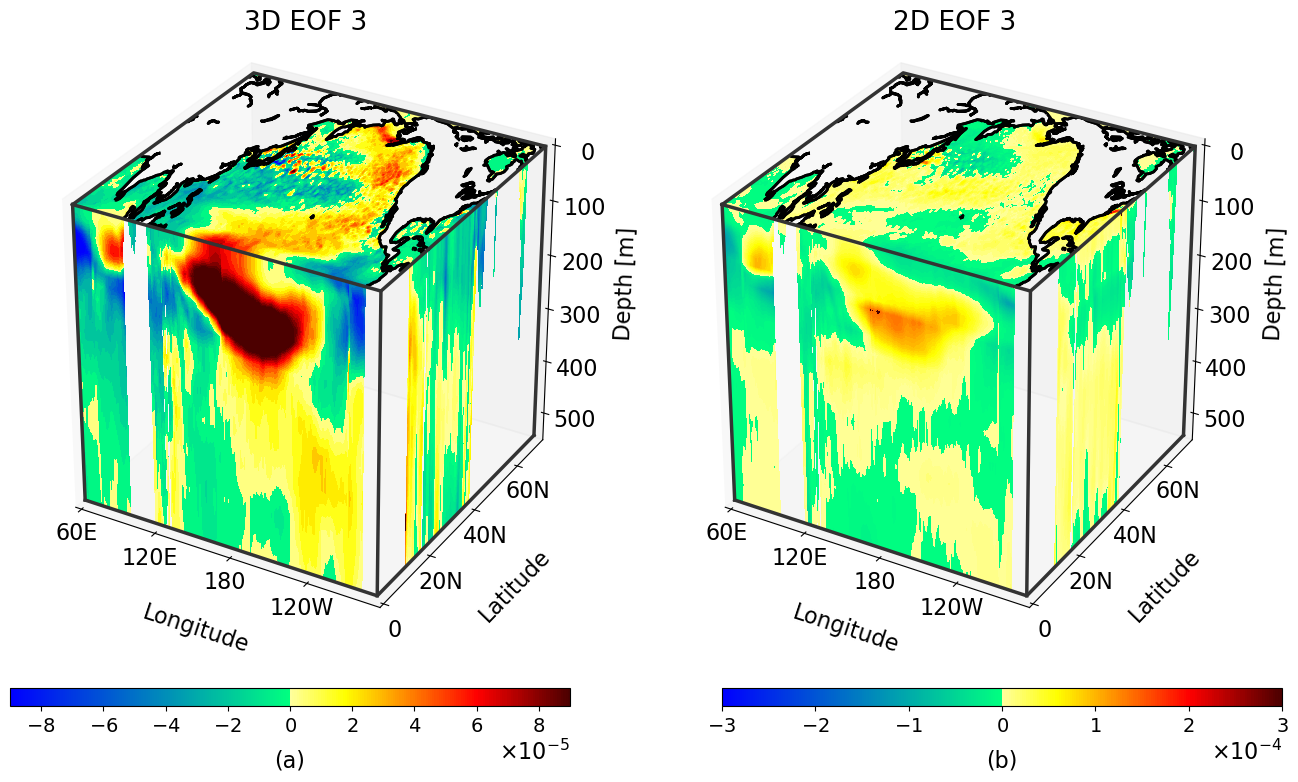

In [18]:
# --- Setup Figure ---
fig = plt.figure(figsize=(16, 9))
plt.subplots_adjust(wspace=0.1)
levels = 50

# --- Tick Configuration ---
lon_ticks   = np.arange(60, lonNum, 60)
lat_ticks   = np.arange(0, 81, 20)
depth_ticks = np.arange(0, depths.max() + 1, 100)

# --- Z-limits ---
# zlim_left = 0.0003
# zlim_right = 0.00009

# --- Clipping and color norm ---


# norm_left = mpl.colors.Normalize(vmin=-zlim_left, vmax=zlim_left)
# norm_right = mpl.colors.Normalize(vmin=-zlim_right, vmax=zlim_right)

# --- Plot Helper Function ---
def configure_3d_axes(ax, xticks, yticks, zticks, title):
    ax.grid(False)
    ax.set_xticks(xticks, labels=[format_longitude(int(l)) for l in xticks], fontsize=label_sz)
    ax.set_yticks(yticks, labels=[format_latitude(int(l)) for l in yticks], fontsize=label_sz)
    ax.set_zticks(-zticks, labels=[f"{t:.0f}" for t in zticks], fontsize=label_sz)
    ax.tick_params(axis='x', pad=-2, labelsize=label_sz)
    ax.tick_params(axis='y', pad=0,  labelsize=label_sz)
    ax.tick_params(axis='z', pad=7,  labelsize=label_sz)
    ax.set_xlabel('Longitude', fontsize=label_sz, labelpad=13)
    ax.set_ylabel('Latitude', fontsize=label_sz, labelpad=16)
    ax.set_zlabel('Depth [m]', fontsize=label_sz, labelpad=16, rotation=0)
    ax.set_title(title, fontsize=title_sz)
    ax.set_xlim(lons.min(), lons.max())
    ax.set_ylim(lats.min(), lats.max())
    ax.set_zlim(-depths.max(), 0)
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=30, azim=-60)

    # Box edges
    xmin, xmax = lons.min(), lons.max()
    ymin, ymax = lats.min(), lats.max()
    zmin, zmax = -depths.max(), 0
    edges_kw = dict(color='0.2', linewidth=2.5, zorder=100)

    ax.plot([xmin, xmax, xmax], [ymin, ymin, ymax], [zmin]*3, **edges_kw)
    ax.plot([xmin, xmax, xmax, xmin, xmin], [ymin, ymin, ymax, ymax, ymin], [zmax]*5, **edges_kw)
    for x in (xmin, xmax):
        for y in (ymin, ymax):
            if not (x == xmin and y == ymax):  # skip back-left
                ax.plot([x, x], [y, y], [zmin, zmax], **edges_kw)

# === 3D EOF Plot (Left) ===
ax2 = fig.add_subplot(121, projection='3d')

cs2 = ax2.contourf(X[:, :, 0], Y[:, :, 0], surface3D, zdir='z', offset=-depths[iz],
                   levels=levels, cmap=newcmp2, norm=norm_left, alpha=1, extend='both', vmin=-zlim_left, vmax=zlim_left)
ax2.contourf(X[0, :, :], lat_depth3D.T, Z[0, :, :], zdir='y', levels=levels, cmap=newcmp2,
             norm=norm_left, alpha=1, vmin=-zlim_left, vmax=zlim_left, extend='both')
ax2.contourf(lon_depth3D.T, Y[:, -1, :], Z[:, -1, :], zdir='x', offset=lonNum, levels=levels,
             cmap=newcmp2, norm=norm_left, alpha=1, vmin=-zlim_left, vmax=zlim_left, extend='both')

m2 = Basemap(projection='cyl', llcrnrlon=lons.min(), urcrnrlon=lons.max(),
             llcrnrlat=lats.min(), urcrnrlat=lats.max())
ax2.add_collection3d(m2.drawcoastlines(linewidth=2), zs=-depths[iz], zdir='z')

configure_3d_axes(ax2, lon_ticks, lat_ticks, depth_ticks, f"3D EOF {mode}")
#ax2.text2D(0.02, 0.95, "(a)", transform=ax2.transAxes, fontsize=18, fontweight='bold')

# === 2D EOF Plot (Right) ===
ax = fig.add_subplot(122, projection='3d')

cs = ax.contourf(X[:, :, 0], Y[:, :, 0], surface, zdir='z', offset=-depths[iz],
                 levels=levels, cmap=newcmp2, norm=norm_right, alpha=1, extend='both', vmin=-zlim_right, vmax=zlim_right)
ax.contourf(X[0, :, :], lat_depth.T, Z[0, :, :], zdir='y', levels=levels,
            cmap=newcmp2, norm=norm_right, alpha=1, vmin=-zlim_right, vmax=zlim_right, extend='both')
ax.contourf(lon_depth.T, Y[:, -1, :], Z[:, -1, :], zdir='x', offset=lonNum, levels=levels,
            cmap=newcmp2, norm=norm_right, alpha=1, vmin=-zlim_right, vmax=zlim_right, extend='both')

m = Basemap(projection='cyl', llcrnrlon=lons.min(), urcrnrlon=lons.max(),
            llcrnrlat=lats.min(), urcrnrlat=lats.max())
ax.add_collection3d(m.drawcoastlines(linewidth=2), zs=-depths[iz], zdir='z')

configure_3d_axes(ax, lon_ticks, lat_ticks, depth_ticks, f"2D EOF {mode}")
# ax.text2D(0.02, 0.95, "(b)", transform=ax.transAxes, fontsize=18, fontweight='bold')

# === Separate Colorbars BELOW the plots ===

# Left colorbar (under left plot)
sm_left = mpl.cm.ScalarMappable(norm=norm_left, cmap=newcmp2)
sm_left.set_array([])
cbar_ax_left = fig.add_axes([0.125, 0.08, 0.35, 0.02])  # [left, bottom, width, height]
cbar_left = fig.colorbar(sm_left, cax=cbar_ax_left, orientation='horizontal',
                         format=mpl.ticker.ScalarFormatter(useMathText=True))
cbar_left.ax.tick_params(labelsize=14, direction='out')
cbar_left.ax.xaxis.get_offset_text().set_fontsize(label_sz)
cbar_left.formatter.set_powerlimits((0, 0))
cbar_left.update_ticks()
cbar_left.set_label("(a)", fontsize=16, labelpad=10, loc='center')

# Right colorbar (under right plot)
sm_right = mpl.cm.ScalarMappable(norm=norm_right, cmap=newcmp2)
sm_right.set_array([])
cbar_ax_right = fig.add_axes([0.57, 0.08, 0.35, 0.02])  # [left, bottom, width, height]
cbar_right = fig.colorbar(sm_right, cax=cbar_ax_right, orientation='horizontal',
                          format=mpl.ticker.ScalarFormatter(useMathText=True))
cbar_right.ax.tick_params(labelsize=14, direction='out')
cbar_right.ax.xaxis.get_offset_text().set_fontsize(label_sz)
cbar_right.formatter.set_powerlimits((0, 0))
cbar_right.update_ticks()
cbar_right.set_label("(b)", fontsize=16, labelpad=10, loc='center')

# --- Show Plot ---
saveName = "D:/SCIL/Paper Figs/" + region + "/Cross Sections/Cube_" + region + "_mode_" + str(mode)
#plt.savefig(saveName, bbox_inches='tight', dpi = 700)
plt.show()


# Figure 8

## Data Wrangling

In [19]:
#################################################################################################################
#################################################################################################################
# Function reads in raw cut anomalies
#
# Input:
#         - year: int with the specific year to read
# Output:
#         - anom: 3D array of dim (depth, lat, lon) with the anomaly data
def read_anom_raw(year):
    fn   = 'Winter.anom.mon.'+str(year)+'.nc'        # change directory
    fn   = os.path.join(anomalies_directory, fn)  # join with the directory that can be changed
    nc0 = ds(fn, 'r')
    anom = nc0.variables['anom'][:depth_end, lat_start:lat_end, lon_start:lon_end]
    anom = anom.filled()
    nc0.close()
    return anom
#################################################################################################################
#################################################################################################################
# Function reads in cut anomalies, will tak eout NaNs, and then flattten to a 1D array
#
# Input:
#         - year: int with the year to read in
# Output:
#         - anom: 1d array that contains anomalies of the file without any NaN
def read_cut_anom_compressed(year,lat_cut_start,lat_cut_end, lon_cut_start, lon_cut_end):
    fn   = 'Winter.anom.mon.'+str(year)+'.nc'        # change directory
    fn   = os.path.join(anomalies_directory, fn)  # join with the directory that can be changed
    nc0  = ds(fn, 'r')
    anom = nc0.variables['anom'][0, lat_cut_start:lat_cut_end, lon_cut_start:lon_cut_end]
    anom = anom.compressed()                        # flatttentens and gets rid of NaN
    #anom = anom.filled()
    nc0.close()
    return anom
#################################################################################################################
#################################################################################################################
# Function wil read clinatologies at the cut given
# Input:
#        - depth_end: Int defining what depth level to stop it
#        - lat_start: Int defining which lat to start at
#        - lat_end: Int defining which lat to stop at
#        - lon_start: Int defining which lon to start
#        - lon_end: Int defining which lon to end at
# Output:
#         - clim: 3D float array with the climatologies at a defined cut
def read_sdev_compressed(lat_cut_start,lat_cut_end, lon_cut_start, lon_cut_end):
    fn = 'Winter.mon.sdev.nc'
    # read in climatologies
    fn = os.path.join(anomalies_directory, fn)
    nc0 = ds(fn, 'r')
    sdev = nc0.variables['sdev'][0, lat_cut_start:lat_cut_end, lon_cut_start:lon_cut_end] 
    sdev = sdev.compressed()               # cut clim
    nc0.close()
    return sdev

import pandas as pd
'''
Read eigenvalues and eigenvectors from the Excel file.

Parameters:
-----------
month : str
    Month identifier used in the filename
EOF_directory : str
    Directory where the file is stored

Returns:
--------
eigvals : numpy.ndarray
    Array of eigenvalues with shape (n_eigvals, n_depths)
eigvecs : numpy.ndarray
    Array of eigenvectors with shape (n_depths, n_locations, n_eigvals)
'''
def read_evals(month, EOF_directory):

    
    # Construct filename
    fn = month + '_eigenvalues_eigenvectors.xlsx'
    #EOF_directory = os.path.join(data_directory, '2D EOFs/Entire Ocean')
    fn = os.path.join(EOF_directory, fn)
    
    # Read all sheets from the Excel file
    xl_file = pd.ExcelFile(fn)
    
    # Get the number of depth bins from sheet names
    sheet_names = xl_file.sheet_names
    n_depths = len(sheet_names)
    
    # Read first sheet to get dimensions
    df_first = pd.read_excel(xl_file, sheet_name=sheet_names[0], index_col=0)
    n_eigvals = len(df_first)  # number of rows
    n_locations = df_first.shape[1] - 1  # excluding eigenvalue column
    
    # Initialize arrays
    eigvals = np.zeros((n_eigvals, n_depths))
    eigvecs = np.zeros((n_depths, n_locations, n_eigvals))
    
    # Read data from each sheet
    for depth_idx, sheet_name in enumerate(sheet_names):
        df = pd.read_excel(xl_file, sheet_name=sheet_name, index_col=0)
        
        # Extract eigenvalues (first column)
        eigvals[:, depth_idx] = df.iloc[:, 0].values
        
        # Extract eigenvectors (remaining columns)
        # Note: eigenvectors are stored transposed in the file
        eigvecs[depth_idx, :, :] = df.iloc[:, 1:].values.T
    
    return eigvals, eigvecs

In [20]:
month

'Winter Avg'

In [21]:
_, eigvecs = read_evals('Winter Avg', EOF_directory)

In [22]:

#depths_flipped_2 = [1, 3, 4, 6, 7, 8, 9, 10, 14, 16, 18, 19, 23, 25, 27, 29, 33, 36, 38, 39, 41, 45, 46, 47]
depths_flipped_2 = [0, 1, 2, 7, 9, 10, 14, 16, 19, 23, 25, 27, 29, 32, 34, 36, 37, 38, 39, 40, 42, 43, 44, 48, 49] # These are my layers
#depths_flipped_3 = [0, 2, 3, 4, 6, 10, 11, 18, 19, 20, 21, 22, 24, 27, 31, 34, 35, 36, 39, 40, 41, 43, 44, 46]
depths_flipped_3 =  [1, 5, 6, 9, 10, 12, 13, 14, 15, 16, 17, 19, 20, 21, 22, 24, 25, 27, 28, 31, 32, 33, 35, 36, 46, 47] # These are my layers

mode = 3
for depth_ind in range(len(depths)):
    if any(x == depth_ind for x in depths_flipped_3):
        eigvecs[depth_ind,:,mode-1] = -eigvecs[depth_ind,:,mode-1]
mode = 2
for depth_ind in range(len(depths)):
    if any(x == depth_ind for x in depths_flipped_2):
        eigvecs[depth_ind,:,mode-1] = -eigvecs[depth_ind,:,mode-1]

In [23]:
fn     = 'Winter Avg_eigenvalues_eigenvectors.csv'
EOF_directory = os.path.join(data_directory, 'cut_EOFs/Winter Avg/Global' )
fn     = os.path.join(EOF_directory, fn)
df = pd.read_csv(fn)

# Extract the eigenvalues
_ = df['Eigenvalue'].values

# Extract the eigenvectors
eigvecs3D = df.drop(columns=['Eigenvalue']).values.T

# Correctly orient EOF 3
eigvecs3D[:, 2] *= -1


### Meridional Modes

In [24]:
indices = pd.read_csv('D:/SCIL/pmm_indices.csv')
SPMM = -indices['SPMM'].values
NPMM = -indices['NPMM'].values
AMM = indices['AMM'].values

### TNI

In [25]:
#Nino 1+2
lat_cut_start = 840#120
lat_cut_end = 961#240
lon_cut_start = 3240#1800
lon_cut_end = 3361#1920
NINO12_GLORYS = np.zeros((len(years)))
for k,year in enumerate(years):
    anom = read_cut_anom_compressed(year,lat_cut_start,lat_cut_end, lon_cut_start, lon_cut_end)
    sdev = read_sdev_compressed(lat_cut_start,lat_cut_end, lon_cut_start, lon_cut_end)
    anom = anom/sdev
    NINO12_GLORYS[k] = np.mean(anom)
    
# Nino 4
lat_cut_start = 900#180
lat_cut_end = 1021#300
lon_cut_start = 1920#480
lon_cut_end = 2521#1080
NINO4_GLORYS = np.zeros((len(years)))
for k,year in enumerate(years):
    anom = read_cut_anom_compressed(year,lat_cut_start,lat_cut_end, lon_cut_start, lon_cut_end)
    sdev = read_sdev_compressed(lat_cut_start,lat_cut_end, lon_cut_start, lon_cut_end)
    anom = anom/sdev
    NINO4_GLORYS[k] = np.mean(anom)

#N12 = (NINO12_GLORYS - NINO12_GLORYS.mean())/NINO12_GLORYS.std()
#N4 = (NINO4_GLORYS - NINO4_GLORYS.mean())/NINO4_GLORYS.std()
TNI_GLORYS = NINO12_GLORYS - NINO4_GLORYS


import requests
import io
# Step 1: Download the file
#url = "https://psl.noaa.gov/data/correlation/nina4.data"  # Replace with your .dat file URL
url = "https://psl.noaa.gov/data/correlation/nina1.data"
response = requests.get(url)

# Step 2: Check for successful response
if response.status_code == 200:
    # Step 3: Load the file (use numpy here as an example for structured data)
    data = pd.read_csv(io.StringIO(response.text), skiprows=1, delim_whitespace=True, header=None)
    print('set')
else:
    print("Failed to download the file.")

NOAA12 = data.values[46:74,1].astype(np.float32)

url = "https://psl.noaa.gov/data/correlation/nina4.data"  # Replace with your .dat file URL
#url = "https://psl.noaa.gov/data/correlation/nina1.data"
response = requests.get(url)

# Step 2: Check for successful response
if response.status_code == 200:
    # Step 3: Load the file (use numpy here as an example for structured data)
    data = pd.read_csv(io.StringIO(response.text), skiprows=1, delim_whitespace=True, header=None)
    print('set')
else:
    print("Failed to download the file.")

NOAA4 = data.values[46:74,1].astype(np.float32)
NOAA_TNI = NOAA12 - NOAA4

set
set


In [26]:
month

'Winter Avg'

### EMI

In [27]:

lat_cut_start = 840
lat_cut_end = 1080
lon_cut_start = 1980
lon_cut_end = 2640

A = np.zeros((len(years)))
for k,year in enumerate(years):
    anom = read_cut_anom_compressed(year,lat_cut_start,lat_cut_end, lon_cut_start, lon_cut_end)
    A[k] = np.mean(anom)

lat_cut_start = 780
lat_cut_end = 1020
lon_cut_start = 3000
lon_cut_end = 3480

B = np.zeros((len(years)))
for k,year in enumerate(years):
    anom = read_cut_anom_compressed(year,lat_cut_start,lat_cut_end, lon_cut_start, lon_cut_end)
    B[k] = np.mean(anom)

lat_cut_start = 840
lat_cut_end = 1200
lon_cut_start = 1500
lon_cut_end = 1740

C = np.zeros((len(years)))
for k,year in enumerate(years):
    anom = read_cut_anom_compressed(year,lat_cut_start,lat_cut_end, lon_cut_start, lon_cut_end)
    C[k] = np.mean(anom)
EMI_GLORYS = A - .5 * B - .5 * C

## Plot

In [28]:
from scipy.stats import pearsonr

mode = 2
p_value1 = np.zeros(len(depths))
p_value2 = np.zeros(len(depths))
p_value3 = np.zeros(len(depths))

correlation1 = np.zeros(len(depths))
correlation2 = np.zeros(len(depths))
correlation3 = np.zeros(len(depths))

for depth_ind in range(len(depths)):
  #  if any(x == depth_ind for x in depths_flipped_2):
    #    eigvecs[depth_ind,:,mode-1] = -eigvecs[depth_ind,:,mode-1]
    correlation1[depth_ind], p_value1[depth_ind] = pearsonr(SPMM, eigvecs[depth_ind,:,mode-1])
    correlation2[depth_ind], p_value2[depth_ind] = pearsonr(NPMM, eigvecs[depth_ind,:,mode-1])
    correlation3[depth_ind], p_value3[depth_ind] = pearsonr(AMM, eigvecs[depth_ind,:,mode-1])

mode = 3
p_value11 = np.zeros(len(depths))
p_value22 = np.zeros(len(depths))
p_value33 = np.zeros(len(depths))

correlation11 = np.zeros(len(depths))
correlation22 = np.zeros(len(depths))
correlation33 = np.zeros(len(depths))

for depth_ind in range(len(depths)):
    #if any(x == depth_ind for x in depths_flipped_3):
     #   eigvecs[depth_ind,:,mode-1] = -eigvecs[depth_ind,:,mode-1]
    correlation11[depth_ind], p_value11[depth_ind] = pearsonr(SPMM, -eigvecs[depth_ind,:,mode-1])
    correlation22[depth_ind], p_value22[depth_ind] = pearsonr(EMI_GLORYS, -eigvecs[depth_ind,:,mode-1])
    #correlation33[depth_ind], p_value33[depth_ind] = pearsonr(AMM, -eigvecs[depth_ind,:,mode-1])
    correlation33[depth_ind], p_value33[depth_ind] = pearsonr(NPMM, -eigvecs[depth_ind,:,mode-1])


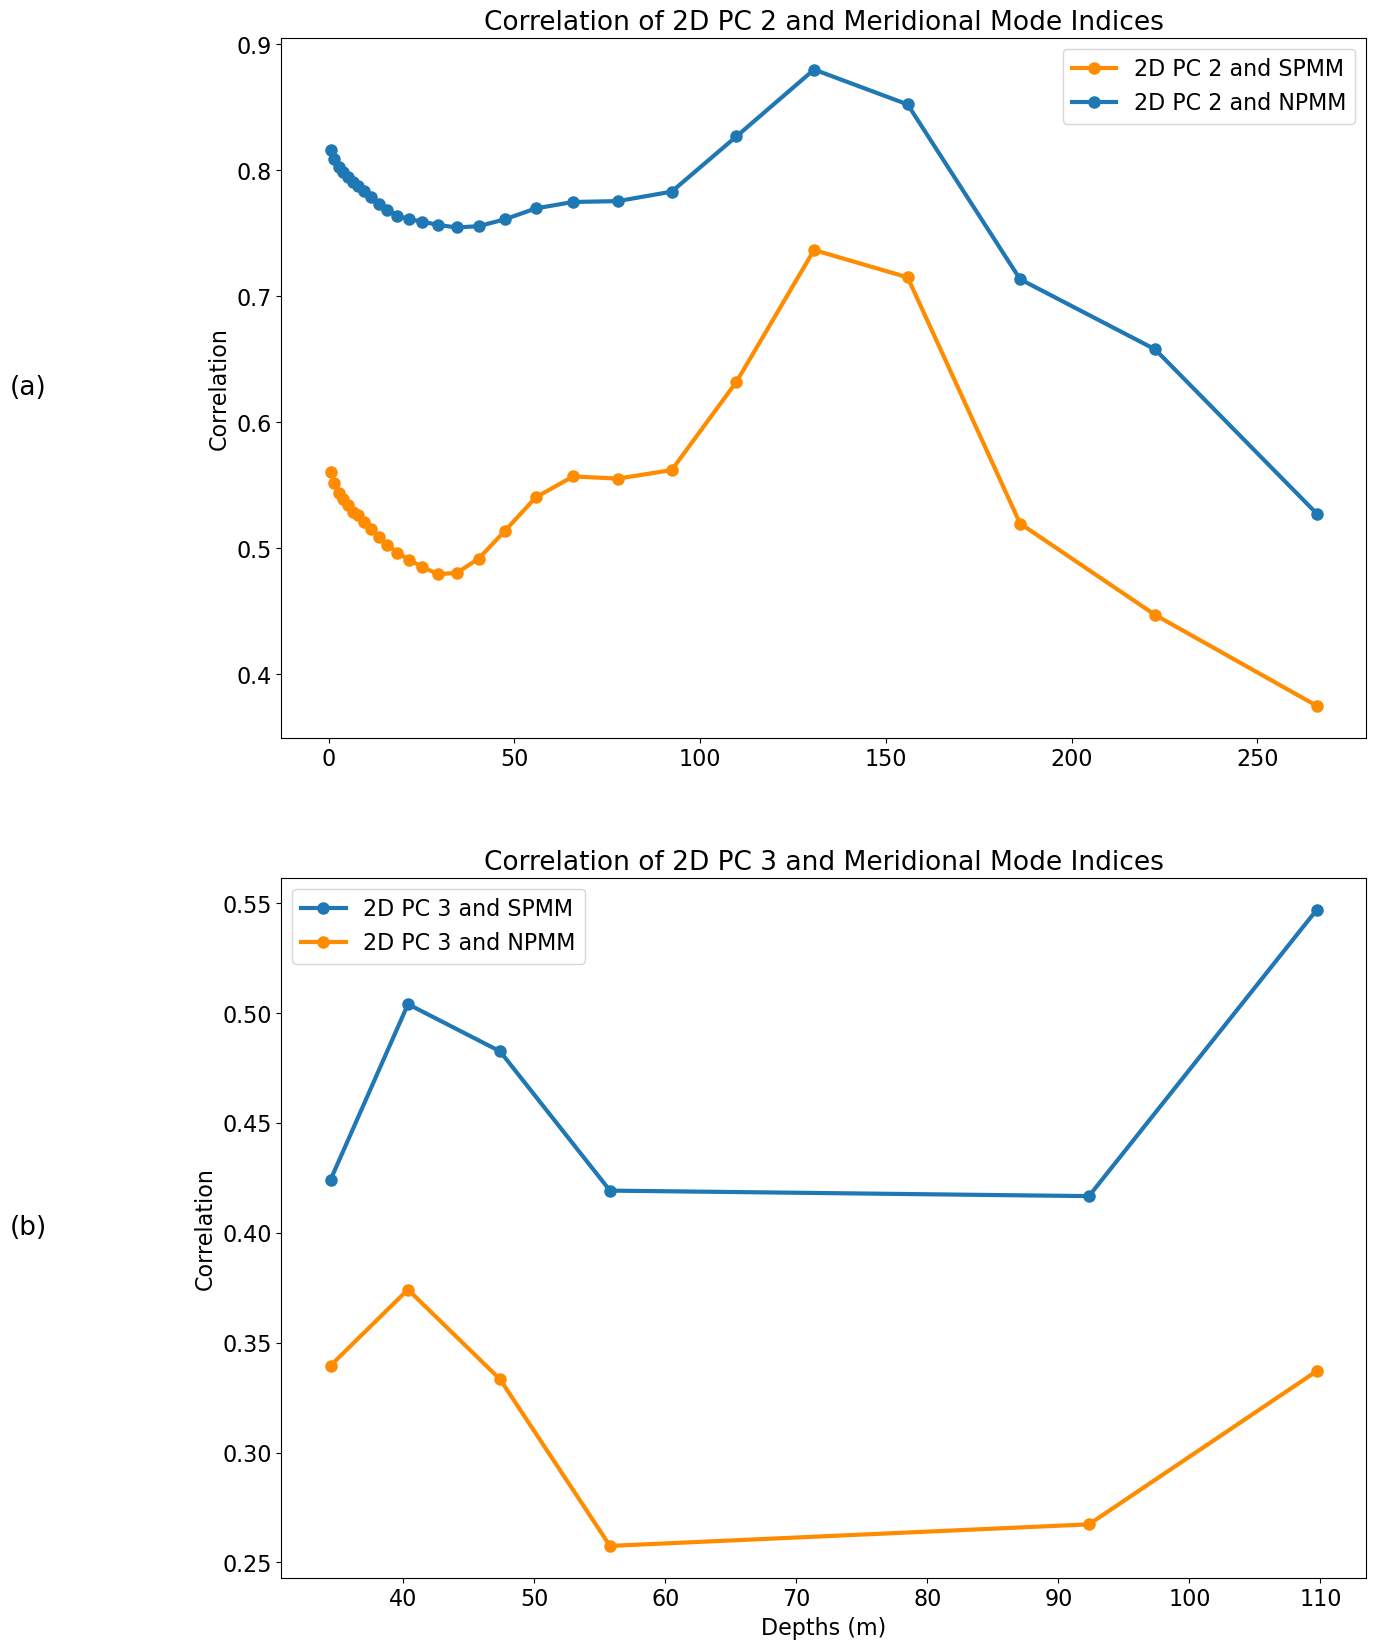

In [29]:
fig = plt.figure(figsize=(14, 20))
# title_sz = 30
# label_sz = title_sz-3
# tick_sz = 5
line = 3

ax1 = plt.subplot(2, 1, 1)

plt.plot(depths[np.where(p_value1<.05)],correlation1[np.where(p_value1<.05)], color='darkorange', marker = 'o', linewidth=line, markersize = line+5, label = '2D PC 2 and SPMM')
plt.plot(depths[np.where(p_value2<.05)],correlation2[np.where(p_value2<.05)], marker = 'o', linewidth=line, markersize = line+5, label = '2D PC 2 and NPMM')

plt.title('Correlation of 2D PC 2 and Meridional Mode Indices', fontsize = title_sz)

plt.ylabel('Correlation', fontsize = label_sz)
plt.legend(fontsize = label_sz)

plt.xticks(fontsize = label_sz)
plt.yticks(fontsize = label_sz)

ax1.text(-.25, 0.5, "(a)", transform=ax1.transAxes, va='center', fontsize = title_sz)


ax2 = plt.subplot(2, 1, 2)

ind = np.where(p_value11<.05)[0]
plt.plot(depths[ind],correlation11[ind],marker = 'o', linewidth=line, markersize = line+5, label = '2D PC 3 and SPMM')
plt.plot(depths[np.where(p_value11<.05)],correlation33[np.where(p_value11<.05)], color='darkorange', marker = 'o', linewidth=line, markersize = line+5, label = '2D PC 3 and NPMM')


plt.title('Correlation of 2D PC 3 and Meridional Mode Indices', fontsize = title_sz)
plt.xlabel('Depths (m)', fontsize = label_sz)
plt.ylabel('Correlation', fontsize = label_sz)
ax1.text(-.25, 0.5, "(b)", transform=ax2.transAxes, va='center', fontsize = title_sz)

plt.legend(fontsize = label_sz)

plt.xticks(fontsize = label_sz)
plt.yticks(fontsize = label_sz)

plt.show()

# Figure 9

In [30]:
p_value_TNI2 = np.zeros(len(depths))
correlation_TNI2 = np.zeros(len(depths))
p_value_TNI3 = np.zeros(len(depths))
correlation_TNI3 = np.zeros(len(depths))

for depth_ind in range(len(depths)):
    correlation_TNI2[depth_ind], p_value_TNI2[depth_ind] = pearsonr(TNI_GLORYS, eigvecs[depth_ind,:,1])
    correlation_TNI3[depth_ind], p_value_TNI3[depth_ind] = pearsonr(TNI_GLORYS, -eigvecs[depth_ind,:,2])

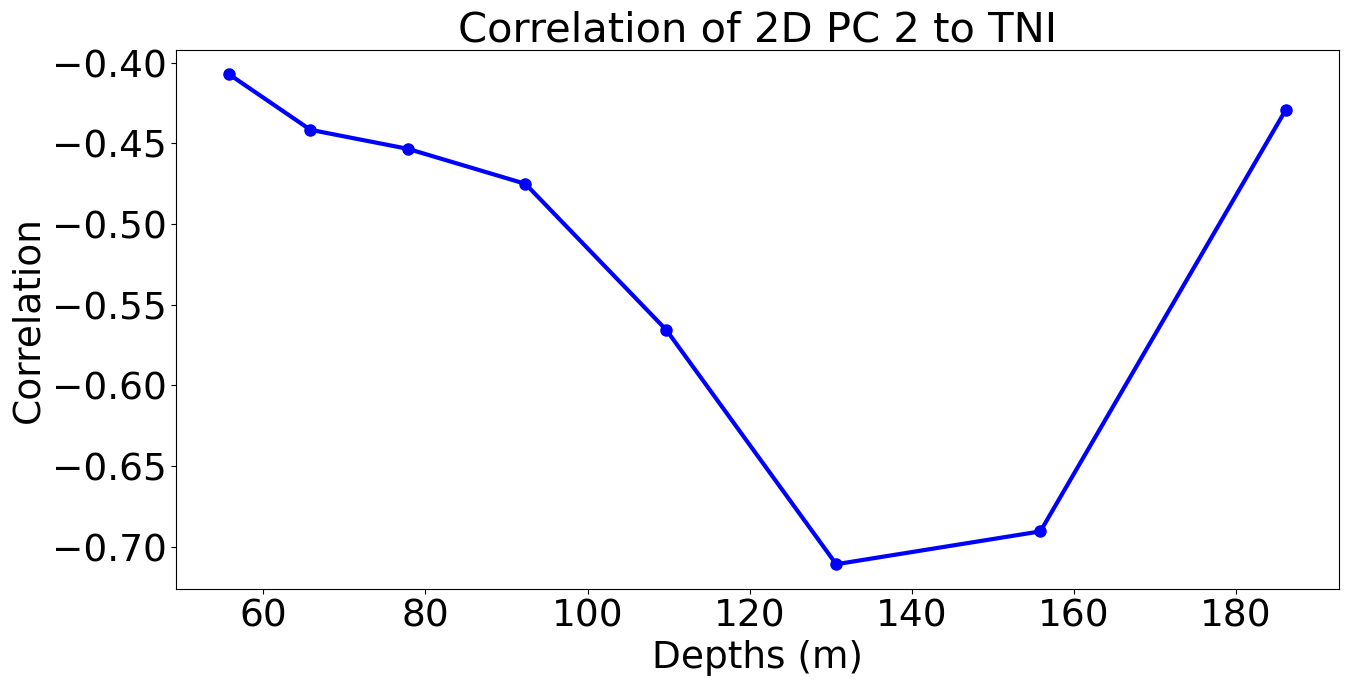

In [31]:
import matplotlib.patches as patches
fig = plt.figure(figsize=(15, 7))
title_sz = 30
label_sz = title_sz-3
tick_sz = 5
line = 3


ax2 = plt.subplot(1, 1, 1)
plt.title('Correlation of 2D PC 2 to TNI', fontsize = title_sz)

foo = correlation_TNI2[np.where(p_value_TNI2<.05)]
foo_d = depths[np.where(p_value_TNI2<.05)]
ind = np.where(foo_d<600)
plt.plot(foo_d[ind],foo[ind], 'b', marker = 'o', 
         linewidth=line, markersize = line+5, label = 'PC2 and TNI')

  
plt.xlabel('Depths (m)', fontsize = label_sz)
plt.ylabel('Correlation', fontsize = label_sz)
  

plt.xticks(fontsize = label_sz)
plt.yticks(fontsize = label_sz)

plt.show()

# Figure 10

In [32]:
from scipy.stats import pearsonr

mode = 2
p2_value1 = np.zeros(len(depths))
p2_value2 = np.zeros(len(depths))
p2_value3 = np.zeros(len(depths))

correlation2_1 = np.zeros(len(depths))
correlation2_2 = np.zeros(len(depths))
correlation2_3 = np.zeros(len(depths))

for depth_ind in range(len(depths)):
    correlation2_1[depth_ind], p2_value1[depth_ind] = pearsonr(-eigvecs3D[:,0], eigvecs[depth_ind,:,mode-1])
    correlation2_2[depth_ind], p2_value2[depth_ind] = pearsonr(-eigvecs3D[:,1], eigvecs[depth_ind,:,mode-1])
    correlation2_3[depth_ind], p2_value3[depth_ind] = pearsonr(-eigvecs3D[:,2], eigvecs[depth_ind,:,mode-1])


mode = 3
p3_value1 = np.zeros(len(depths))
p3_value2 = np.zeros(len(depths))
p3_value3 = np.zeros(len(depths))

correlation3_1 = np.zeros(len(depths))
correlation3_2 = np.zeros(len(depths))
correlation3_3 = np.zeros(len(depths))

for depth_ind in range(len(depths)):
    correlation3_1[depth_ind], p3_value1[depth_ind] = pearsonr(-eigvecs3D[:,0], -eigvecs[depth_ind,:,mode-1])
    correlation3_2[depth_ind], p3_value2[depth_ind] = pearsonr(-eigvecs3D[:,1], -eigvecs[depth_ind,:,mode-1])
    correlation3_3[depth_ind], p3_value3[depth_ind] = pearsonr(-eigvecs3D[:,2], -eigvecs[depth_ind,:,mode-1])

# Figure 11

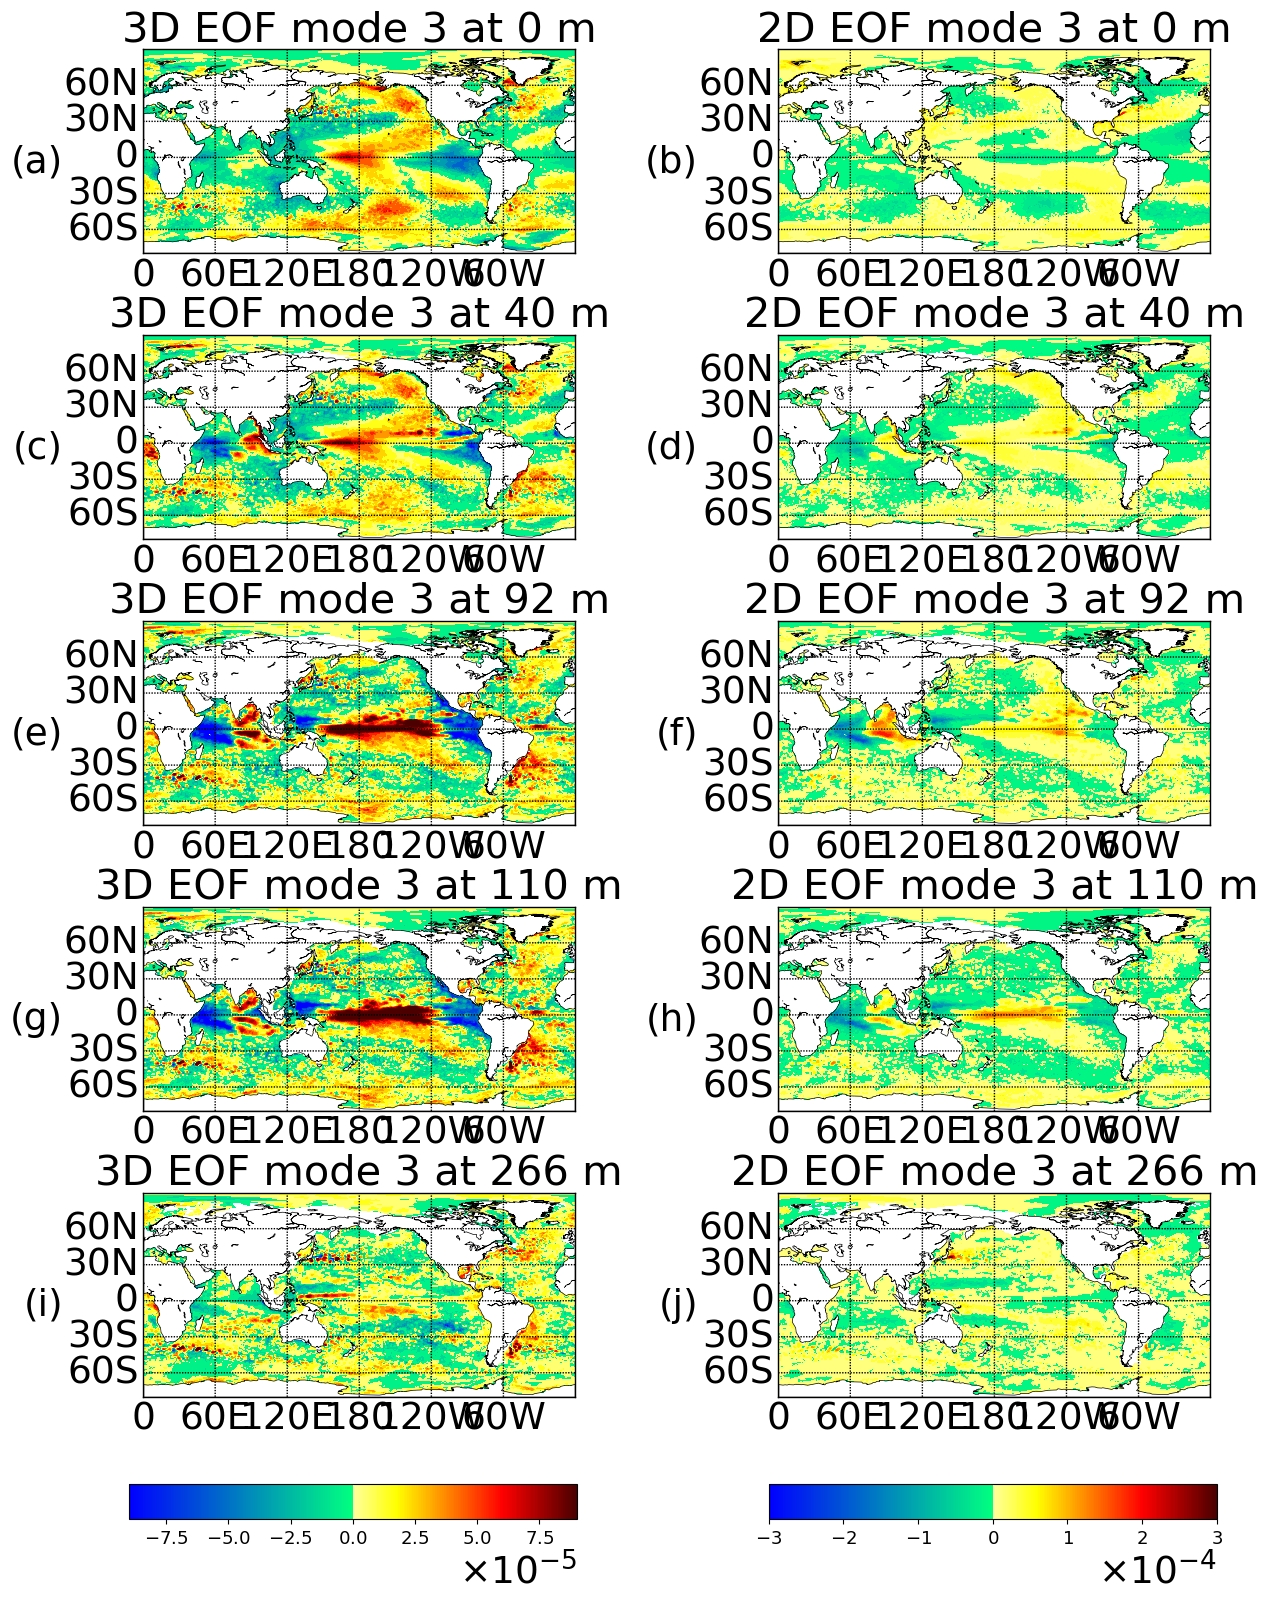

Figure saved to: D:/SCIL/Paper Figs/Global/eof3/EOF_panels_0_16_21_22_27.png


In [33]:
def plot_static_depth_panels(depth_indexes):
    clip2D = 0.0003
    clip3D = 0.00009
    n_panels = len(depth_indexes)

    fig, axes = plt.subplots(n_panels, 2, figsize=(16, 3.5 * n_panels))
    plt.subplots_adjust(wspace=0.05, hspace=0.4)

    norm3D = mpl.colors.Normalize(vmin=-clip3D, vmax=clip3D)
    norm2D = mpl.colors.Normalize(vmin=-clip2D, vmax=clip2D)

    # For labeling panels with (a), (b), ...
    panel_labels = list(string.ascii_lowercase)

    for i, dp in enumerate(depth_indexes):
        if dp >= len(depths):
            print(f"Depth index {dp} out of bounds — skipping.")
            continue

        str_depth = f"{dp:02d}"
        depth = depths[dp]

        dat3D = np.clip(EOF3D[dp, :, :], -clip3D, clip3D)
        dat2D = np.clip(EOF[dp, :, :], -clip2D, clip2D)

        ax3D = axes[i, 0]
        ax2D = axes[i, 1]

        # === 3D Plot ===
        map3D = Basemap(projection='cyl',
                        llcrnrlat=cut_lat[0], urcrnrlat=cut_lat[-1],
                        llcrnrlon=cut_lon[0], urcrnrlon=cut_lon[-1],
                        resolution='c', ax=ax3D)
        map3D.drawcoastlines(color='black', linewidth=0.5)
        map3D.drawmapboundary()
        map3D.drawparallels(np.arange(cut_lat[0]+20, cut_lat[-1], 30),
                            labels=[1, 0, 0, 0], fmt=format_latitude, fontsize=label_sz)
        map3D.drawmeridians(np.arange(cut_lon[0], cut_lon[-1], 60),
                            labels=[0, 0, 0, 1], fmt=format_longitude, fontsize=label_sz)

        ax3D.contourf(cut_lon, cut_lat, dat3D, 20, cmap=newcmp2, norm=norm3D)
        ax3D.set_title(f"3D EOF mode {mode} at {round(depth)} m", size=title_sz)

        # === 2D Plot ===
        map2D = Basemap(projection='cyl',
                        llcrnrlat=cut_lat[0], urcrnrlat=cut_lat[-1],
                        llcrnrlon=cut_lon[0], urcrnrlon=cut_lon[-1],
                        resolution='c', ax=ax2D)
        map2D.drawcoastlines(color='black', linewidth=0.5)
        map2D.drawmapboundary()
        map2D.drawparallels(np.arange(cut_lat[0]+20, cut_lat[-1], 30),
                            labels=[1, 0, 0, 0], fmt=format_latitude, fontsize=label_sz)
        map2D.drawmeridians(np.arange(cut_lon[0], cut_lon[-1], 60),
                            labels=[0, 0, 0, 1], fmt=format_longitude, fontsize=label_sz)

        ax2D.contourf(cut_lon, cut_lat, dat2D, 20, cmap=newcmp2, norm=norm2D)
        ax2D.set_title(f"2D EOF mode {mode} at {round(depth)} m", size=title_sz)

        # === Panel Labels Outside Plots ===
        # Get position of current axes in figure coordinates
        for j, ax in enumerate([ax3D, ax2D]):
            label = f"({panel_labels[i * 2 + j]})"
            bbox = ax.get_position()
            # Place label to the left of the y-axis tick labels
            fig.text(bbox.x0 - 0.05, bbox.y1 - 0.054, label,
                     fontsize=label_sz, va='top', ha='right')

    # === Shared Colorbars (Bottom of Columns) ===
    cbar_ax3D = fig.add_axes([0.17, 0.04, 0.28, 0.02])  # [left, bottom, width, height]
    sm3D = mpl.cm.ScalarMappable(norm=norm3D, cmap=newcmp2)
    sm3D.set_array([])
    cbar3D = fig.colorbar(sm3D, cax=cbar_ax3D, orientation='horizontal',
                          format=mpl.ticker.ScalarFormatter(useMathText=True))
    cbar3D.ax.tick_params(labelsize=13)
    cbar3D.ax.xaxis.get_offset_text().set_fontsize(label_sz)
    cbar3D.formatter.set_powerlimits((0, 0))
    cbar3D.update_ticks()
    #cbar3D.set_label("3D EOF amplitude", fontsize=12)

    cbar_ax2D = fig.add_axes([0.57, 0.04, 0.28, 0.02])
    sm2D = mpl.cm.ScalarMappable(norm=norm2D, cmap=newcmp2)
    sm2D.set_array([])
    cbar2D = fig.colorbar(sm2D, cax=cbar_ax2D, orientation='horizontal',
                          format=mpl.ticker.ScalarFormatter(useMathText=True))
    cbar2D.ax.tick_params(labelsize=13)
    cbar2D.ax.xaxis.get_offset_text().set_fontsize(label_sz)
    cbar2D.formatter.set_powerlimits((0, 0))
    cbar2D.update_ticks()
    #cbar2D.set_label("2D EOF amplitude", fontsize=12)

    # Save figure to PNG
    output_path = f"D:/SCIL/Paper Figs/{region}/eof{mode}/EOF_panels_{'_'.join(map(str, depth_indexes))}.png" 
    #plt.savefig(output_path, bbox_inches='tight', dpi=700)
    plt.show()
    print(f"Figure saved to: {output_path}")



# === Call the function with your depth indexes ===

plot_static_depth_panels(depth_list)


# Figure 12

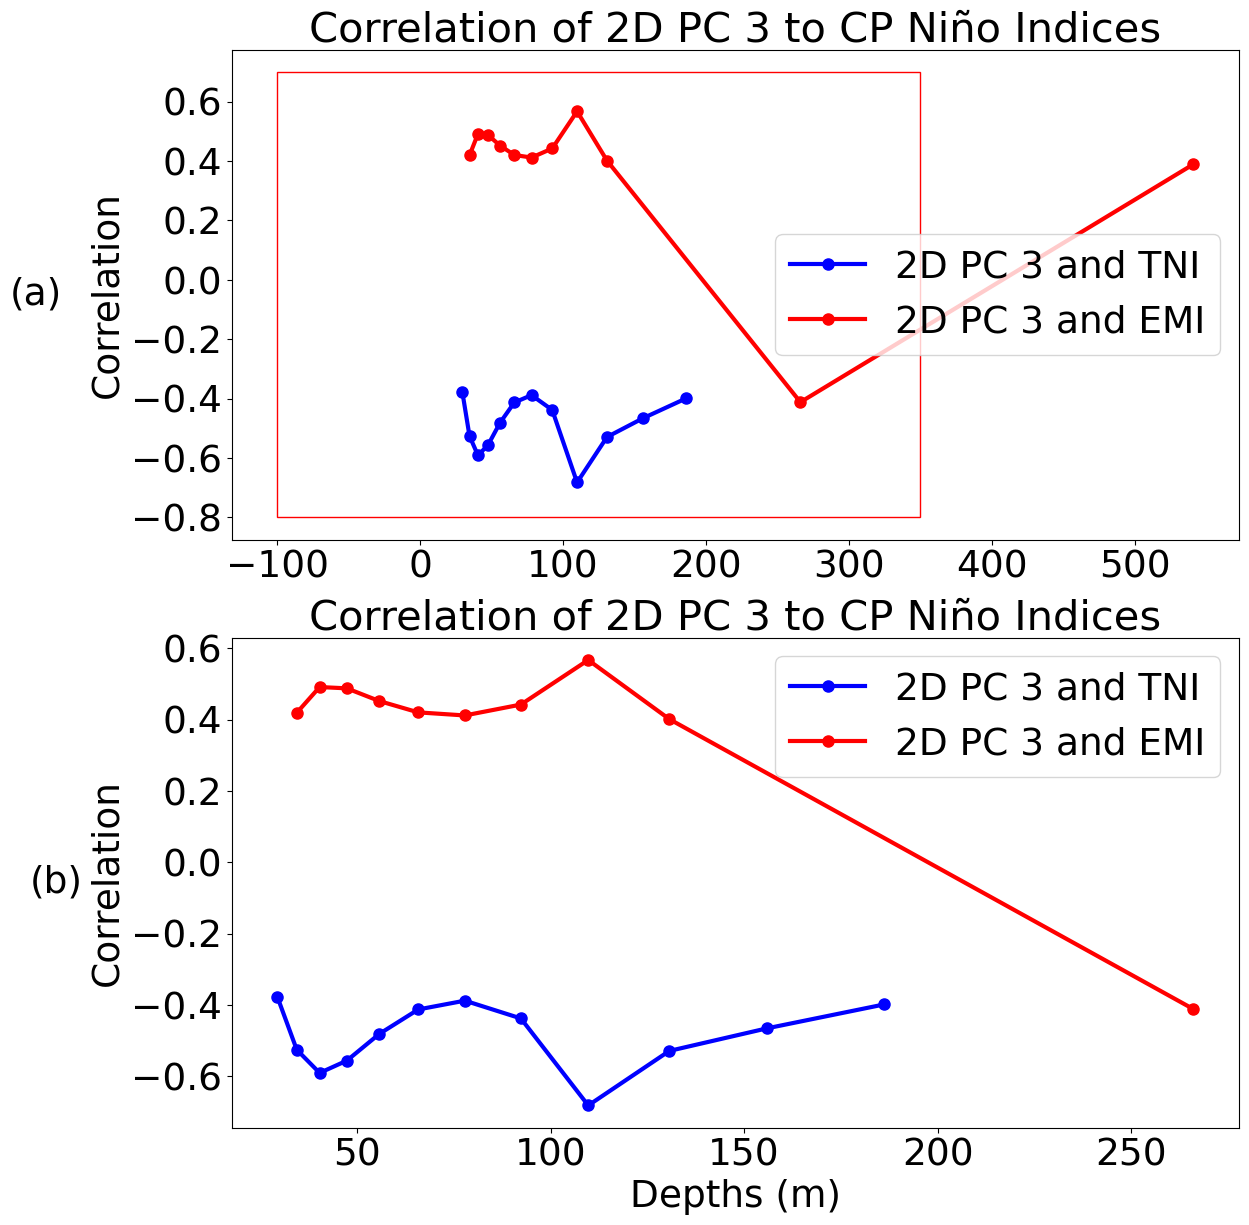

In [34]:
import matplotlib.patches as patches
fig = plt.figure(figsize=(13, 14))

ax1 = plt.subplot(2, 1, 1)
plt.title('Correlation of 2D PC 3 to CP Niño Indices', fontsize = title_sz)
plt.plot(depths[np.where(p_value_TNI3<.05)],correlation_TNI3[np.where(p_value_TNI3<.05)], 'b', marker = 'o', linewidth=line, markersize = line+5, label = '2D PC 3 and TNI')
plt.plot(depths[np.where(p_value22<.05)],correlation22[np.where(p_value22<.05)], 'r', marker = 'o',  
         linewidth=line, markersize = line+5, label = '2D PC 3 and EMI')
plt.ylabel('Correlation', fontsize = label_sz)
ind = np.where(p3_value3<.05)[0]
#plt.plot(depths[ind[:]],correlation3_3[ind[:]],'c', marker = 'o', linewidth=line, markersize = line+5, label = '2D PC 3 and 3D PC 3')


# Create a Rectangle patch
rect = patches.Rectangle((-100,-.8), 450, 1.5, linewidth=1, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax1.add_patch(rect)

plt.legend(fontsize = label_sz)

plt.xticks(fontsize = label_sz)
plt.yticks(fontsize = label_sz)
ax1.text(-.22, 0.5, "(a)", transform=ax1.transAxes, va='center', fontsize = label_sz)


ax2 = plt.subplot(2, 1, 2)
plt.title('Correlation of 2D PC 3 to CP Niño Indices', fontsize = title_sz)

foo = correlation_TNI3[np.where(p_value_TNI3<.05)]
foo_d = depths[np.where(p_value_TNI3<.05)]
ind = np.where(foo_d<600)
plt.plot(foo_d[ind],foo[ind], 'b', marker = 'o', 
         linewidth=line, markersize = line+5, label = '2D PC 3 and TNI')



ind = np.where(p_value22<.05)[0]
plt.plot(depths[ind[:10]],correlation22[ind[:10]], 'r', marker = 'o',
         linewidth=line, markersize = line+5, label = '2D PC 3 and EMI')
plt.legend(fontsize = label_sz)

plt.xlabel('Depths (m)', fontsize = label_sz)
plt.ylabel('Correlation', fontsize = label_sz)
  

plt.xticks(fontsize = label_sz)
plt.yticks(fontsize = label_sz)
ax1.text(-.2, 0.5, "(b)", transform=ax2.transAxes, va='center', fontsize = label_sz)

plt.show()

# Figure 13

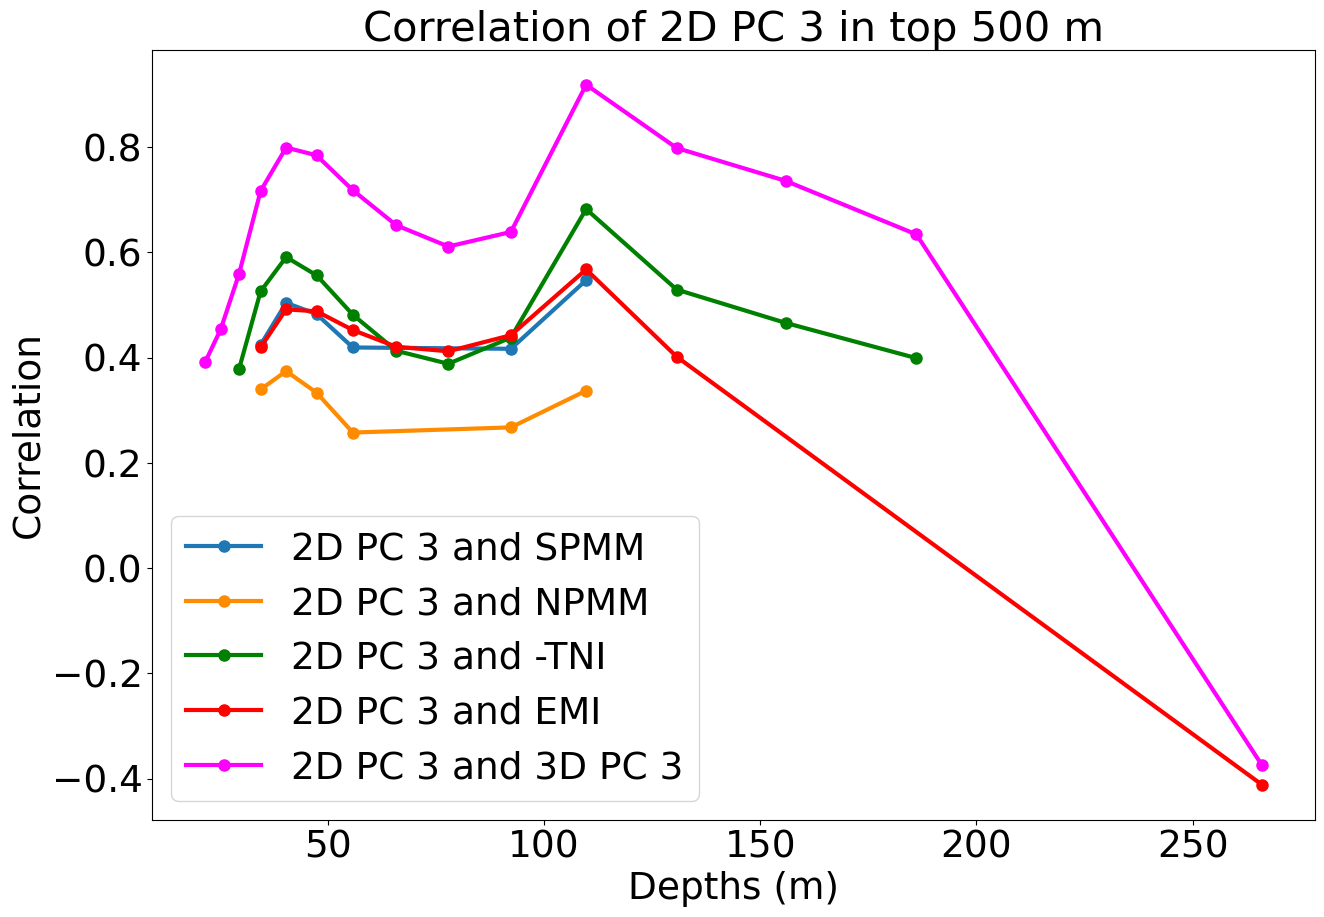

In [35]:
 
fig = plt.figure(figsize=(15, 10))
title_sz = 30
label_sz = title_sz-3
tick_sz = 5
line = 3

plt.plot(depths[np.where(p_value11<.05)],correlation11[np.where(p_value11<.05)], marker = 'o', linewidth=line, markersize = line+5, label = '2D PC 3 and SPMM')
plt.plot(depths[np.where(p_value11<.05)],correlation33[np.where(p_value11<.05)], color='darkorange', marker = 'o', linewidth=line, markersize = line+5, label = '2D PC 3 and NPMM')


foo = correlation_TNI3[np.where(p_value_TNI3<.05)]
foo_d = depths[np.where(p_value_TNI3<.05)]
ind = np.where(foo_d<600)
plt.plot(foo_d[ind],-foo[ind], 'g', marker = 'o', 
         linewidth=line, markersize = line+5, label = '2D PC 3 and -TNI')


ind = np.where(p_value22<.05)[0]
plt.plot(depths[ind[:10]],correlation22[ind[:10]], 'r', marker = 'o',
         linewidth=line, markersize = line+5, label = '2D PC 3 and EMI')
plt.legend(fontsize = label_sz)

ind = np.where(p3_value3<.05)[0]
plt.plot(depths[ind[:15]],correlation3_3[ind[:15]],color = 'magenta', marker = 'o', linewidth=line, markersize = line+5, label = '2D PC 3 and 3D PC 3')


plt.title('Correlation of 2D PC 3 in top 500 m', fontsize = title_sz)
plt.xlabel('Depths (m)', fontsize = label_sz)
plt.ylabel('Correlation', fontsize = label_sz)


plt.legend(fontsize = label_sz)

plt.xticks(fontsize = label_sz)
plt.yticks(fontsize = label_sz)


plt.show()

# Figure 14

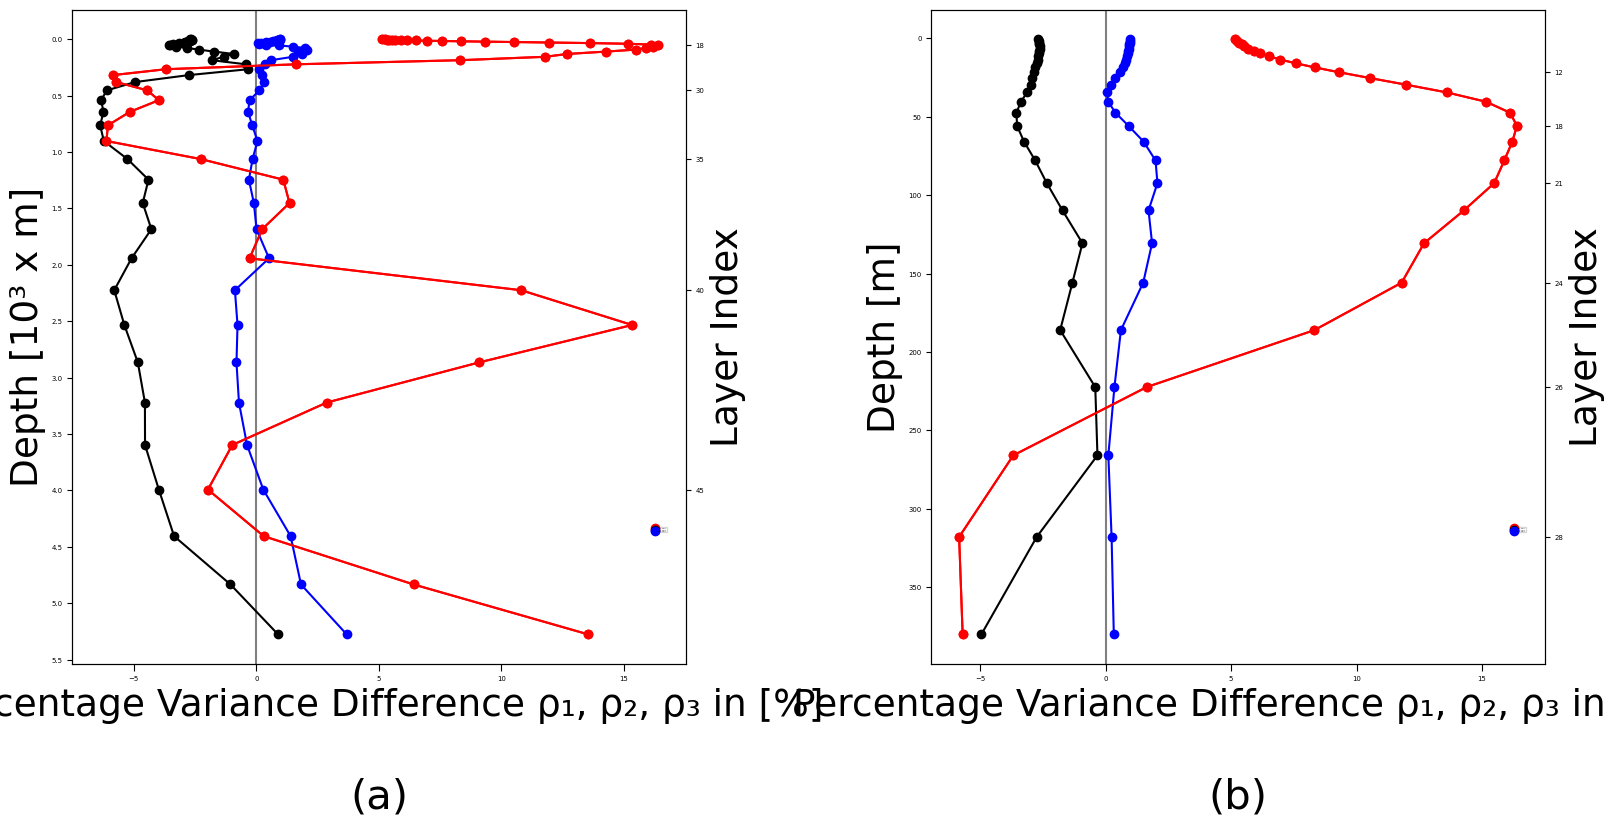

In [36]:

# Create Fig, Ax
fig, ax1 = plt.subplots(1, 2)

# Format 
fig.set_size_inches(19., 8.5)

plt.subplots_adjust(wspace=0.4)


#########################################################################
######## All Depths
#########################################################################
ax1[0].axvline(color = "grey")


ax1[0].plot(mode1diff, depthLayer, color21, marker = 'o', label = label21 + " - " + label31)
ax1[0].plot(mode2diff, depthLayer, color22, marker = "o", label = label22 + " - " + label32)
ax1[0].plot(mode3diff, depthLayer, color23, marker = "o", label = label23 + " - " + label33)

# Format X axis
ax1[0].set_xlabel('Percentage Variance Difference ρ₁, ρ₂, ρ₃ in [%]', size = label_sz)
ax1[0].tick_params('x',size = tick_sz, labelsize = tick_sz)
#ax1.grid(axis = "x")


# Format Left hand y axis
ax1[0].set_ylabel('Depth [10³ x m]', size =label_sz)
step = 500                            # change this for smaller depth intervals
y_labels = ax1[0].get_yticks()
dep_names = np.arange(0,-y_labels[0],step).astype(int)
dep_names_labels = (dep_names/1000).astype(str).tolist()
ax1[0].set_yticks(-dep_names, dep_names_labels, fontsize = tick_sz)
#ax1[0].axhline(y = 0, color='0.65', linestyle='-', label='', lw = '0.8')

# Create right hand y axis
ax2 = ax1[0].twinx()
ax2.plot(mode1diff, depthLayer, color21, marker = 'o')
dep_ind = np.arange(32).astype(str).tolist()

# Select based on depth of plot
indexLabels = [18, 30, 35, 40, 45]

layerIndex = depthLayer[indexLabels]
ax2.set_yticks(layerIndex, indexLabels, fontsize = tick_sz)
ax2.set_ylabel('Layer Index', size =label_sz)
#ax2.grid(axis = "y")

#########################################################################
######## First 400m
#########################################################################
ax1[1].axvline(color = "grey")
ax1[1].plot(mode1diff[:30], depthLayer[:30,], color21, marker = 'o', label = label21 + " - " + label31)
ax1[1].plot(mode2diff[:30], depthLayer[:30,], color22, marker = 'o', label = label22 + " - " + label32)
ax1[1].plot(mode3diff[:30], depthLayer[:30,], color23, marker = 'o', label = label23 + " - " + label33)

# Format X axis
ax1[1].set_xlabel('Percentage Variance Difference ρ₁, ρ₂, ρ₃ in [%]', size = label_sz)
ax1[1].tick_params('x',size = tick_sz, labelsize = tick_sz)


# Format Left hand y axis
ax1[1].set_ylabel('Depth [m]', size =label_sz)
step = 50                            # change this for smaller depth intervals
y_labels2 = ax1[1].get_yticks()
dep_names = np.arange(0,-y_labels2[0],step).astype(int)
ax1[1].set_yticks(-dep_names, dep_names.astype(str).tolist(), fontsize = tick_sz)
#ax1[1].axhline(y = 0, color='0.65', linestyle='-', label='', lw = '0.8')


# Create right hand y axis
ax3 = ax1[1].twinx()
ax3.plot(mode1diff[:30], depthLayer[:30,], color21, marker = 'o',)
#ax3.set_ylim(ax1[1].get_ylim())
dep_ind = np.arange(32).astype(str).tolist()


# Select based on depth of plot
indexLabels2 = [12, 18, 21, 24, 26, 28]     # first 32
#indexLabels = [18, 30, 35, 40, 45]

layerIndex2 = depthLayer[indexLabels2]
ax3.set_yticks(layerIndex2, indexLabels2, fontsize = tick_sz)
ax3.set_ylabel('Layer Index', size =label_sz)
#ax3.grid(axis = "y")


#########################################################################
######## Legend and Title
#########################################################################
# ax1[0].legend(bbox_to_anchor=(1, .35), fontsize = tick_sz-2)
# ax1[1].legend(bbox_to_anchor=(1, .35), fontsize = tick_sz-2)


#fig.suptitle("Departure of 2D % Variance Explained from 3D", size = title_sz)
# # ax1[0].set_title("First 3 Eigenvalues for all depths", size = label_sz)
# # ax1[1].set_title("First 3 Eigenvalues for top 400m", size = label_sz)

# ax1[0].text(0.5,-0.2, "(a)", size=title_sz, ha="center", 
#          transform=ax1[0].transAxes)

# ax1[1].text(0.5,-0.2, "(b)", size=title_sz, ha="center", 
#          transform=ax1[1].transAxes)



ax1[0].legend(ncol=1, bbox_to_anchor=(0.97, 0.2), loc='lower right', fontsize=tick_sz-8)
ax1[1].legend(ncol=1, bbox_to_anchor=(0.97, 0.2), loc='lower right', fontsize=tick_sz-8)

ax1[0].text(0.5,-0.22, "(a)", size=title_sz, ha="center", 
         transform=ax1[0].transAxes)

ax1[1].text(0.5,-0.22, "(b)", size=title_sz, ha="center", 
         transform=ax1[1].transAxes)


saveName = 'D:/SCIL/Paper Figs/' + region + '/3D vs 2D Variance Difference at Depth Layer.png'
plt.savefig(saveName, dpi=300, bbox_inches='tight')
plt.show()